# **Classification**

In [2267]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression #, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score

import statsmodels.api as sm

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from pygam import LinearGAM, s, f, l


from dmba import classificationSummary

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline



import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
%matplotlib inline

In [2268]:
data_dir = Path("Data5")
LOAN3000_CSV = data_dir / 'loan3000.csv'
LOAN_DATA_CSV = data_dir / 'loan_data.csv.gz'
FULL_TRAIN_SET_CSV = data_dir / 'full_train_set.csv.gz'

## **Naive Bayes**

### **The Naive Solution**

In [2269]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         45342 non-null  int64  
 1   status             45342 non-null  object 
 2   loan_amnt          45342 non-null  int64  
 3   term               45342 non-null  object 
 4   annual_inc         45342 non-null  int64  
 5   dti                45342 non-null  float64
 6   payment_inc_ratio  45342 non-null  float64
 7   revol_bal          45342 non-null  int64  
 8   revol_util         45342 non-null  float64
 9   purpose            45342 non-null  object 
 10  home_ownership     45342 non-null  object 
 11  delinq_2yrs_zero   45342 non-null  int64  
 12  pub_rec_zero       45342 non-null  int64  
 13  open_acc           45342 non-null  int64  
 14  grade              45342 non-null  float64
 15  outcome            45342 non-null  object 
 16  emp_length         453

In [2270]:
loan_data.head()

,Unnamed: 0,status,loan_amnt,term,annual_inc,dti,payment_inc_ratio,revol_bal,revol_util,purpose,...,delinq_2yrs_zero,pub_rec_zero,open_acc,grade,outcome,emp_length,purpose_,home_,emp_len_,borrower_score
0,1,Charged Off,2500,60 months,30000,1.00,2.39320,1687,9.4,car,...,1,1,3,4.8,default,1,major_purchase,RENT,> 1 Year,0.65
1,2,Charged Off,5600,60 months,40000,5.55,4.57170,5210,32.6,small_business,...,1,1,11,1.4,default,5,small_business,OWN,> 1 Year,0.80
2,3,Charged Off,5375,60 months,15000,18.08,9.71600,9279,36.5,other,...,1,1,2,6.0,default,1,other,RENT,> 1 Year,0.60
3,4,Charged Off,9000,36 months,30000,10.08,12.21520,10452,91.7,debt_consolidation,...,1,1,4,4.2,default,1,debt_consolidation,RENT,> 1 Year,0.50
4,5,Charged Off,10000,36 months,100000,7.06,3.90888,11997,55.5,other,...,1,1,14,5.4,default,4,other,RENT,> 1 Year,0.55


**Data Dictionary for Your Loan Dataset**  

| Column            | Meaning                                                                                         |
|-------------------|-------------------------------------------------------------------------------------------------|
| Unnamed: 0        | Just an index column (row number). Often created when saving/loading CSVs. Can usually be dropped. |
| status            | Current loan status (e.g., “Current”, “Charged Off”, “Fully Paid”, “Late”).                     |
| loan_amnt         | The amount of money the borrower requested/received for the loan.                              |
| term              | Loan term length (e.g., "36 months" or "60 months").                                           |
| annual_inc        | Borrower’s annual income.                                                                       |
| dti               | Debt-to-Income ratio. A measure of how much of the borrower’s monthly income goes toward debt payments. |
| payment_inc_ratio  | Ratio of loan payment to income. Shows how affordable the loan is relative to income.           |
| revol_bal         | Revolving balance — the borrower’s outstanding balance on revolving credit lines (like credit cards). |
| revol_util        | Revolving utilization rate: percentage of revolving credit used compared to the total available. |
| purpose           | The stated purpose of the loan (e.g., “debt consolidation”, “credit card”, “home improvement”, etc.). |
| home_ownership    | Borrower’s home ownership status (e.g., “MORTGAGE”, “OWN”, “RENT”).                            |
| delinq_2yrs_zero  | Indicator: whether borrower had zero delinquencies in the past 2 years (1 = yes, 0 = no).       |
| pub_rec_zero      | Indicator: whether borrower has zero derogatory public records (e.g., bankruptcies, liens).     |
| open_acc          | Number of open credit lines/accounts the borrower has.                                         |
| grade             | Loan grade assigned by the lender (usually A–G mapped to numeric values). A higher grade = safer borrower. |
| outcome           | Final outcome of the loan (target variable). Often simplified to “paid” vs. “default”.          |
| emp_length        | Number of years borrower has been employed.                                                    |
| purpose_          | Preprocessed/encoded version of purpose.                                                       |
| home_             | Preprocessed/encoded version of home_ownership.                                                |
| emp_len_          | Preprocessed/encoded version of emp_length.                                                    |
| borrower_score    | A derived creditworthiness score for the borrower. Higher = lower risk.                        |

✅ In short:  
Columns like **purpose_**, **home_**, **emp_len_** are transformed versions of the original categorical variables, created for modeling.  
The key prediction target here is **outcome** (loan paid vs. defaulted).



In [2271]:
a = loan_data['borrower_score'].unique()
a.sort()
a

/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/IPython/core/displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [2272]:
loan_data['outcome'].unique()

array(['default', 'paid off'], dtype=object)

In [2273]:
loan_data['purpose_'].unique()

array(['major_purchase', 'small_business', 'other', 'debt_consolidation',
       'credit_card', 'home_improvement', 'medical'], dtype=object)

In [2274]:
loan_data['purpose'].unique()

array(['car', 'small_business', 'other', 'debt_consolidation',
       'major_purchase', 'credit_card', 'home_improvement', 'moving',
       'house', 'medical', 'wedding', 'vacation'], dtype=object)

In [2275]:
loan_data['home_'].unique()

array(['RENT', 'OWN', 'MORTGAGE'], dtype=object)

In [2276]:
loan_data['emp_len_'].unique()

array([' > 1 Year', ' < 1 Year'], dtype=object)

In [2277]:
loan_data['outcome'] = loan_data['outcome'].astype('category')
loan_data['outcome'].unique()

['default', 'paid off']
Categories (2, object): ['default', 'paid off']

In [2278]:
loan_data['outcome'].cat.reorder_categories(['paid off', 'default'])
loan_data['outcome'].unique()

['default', 'paid off']
Categories (2, object): ['default', 'paid off']

In [2279]:
loan_data = pd.read_csv(LOAN_DATA_CSV)

# convert to categorical
loan_data['outcome'] = loan_data['outcome'].astype('category') # Converts the outcome column from generic object (strings) into a categorical type. This makes it more efficient and signals that it’s a set of fixed categories (e.g., paid off, default).
loan_data['outcome'].cat.reorder_categories(['paid off', 'default'])
'''
Reorders the categories of outcome so that 'paid off' is considered before 'default'.
⚠️ Important: this line does not modify the DataFrame in place unless you pass inplace=True or reassign. Otherwise, it just creates a reordered categorical temporarily.
'''
loan_data['purpose_'] = loan_data['purpose_'].astype('category')
loan_data['home_'] = loan_data['home_'].astype('category')
loan_data['emp_len_'] = loan_data['emp_len_'].astype('category')
'''
Converts three more columns (purpose_, home_, emp_len_) to categorical dtype. These are categorical predictors used in the model (e.g., purpose of loan, home ownership, employment length).
'''

predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
'''
Converts categorical predictors into dummy variables (one-hot encoding).
Each category becomes its own binary (0/1) column.
Example: if home_ has values [RENT, MORTGAGE, OWN], this will create columns RENT, MORTGAGE, OWN.
dtype=int makes them integers instead of booleans.
prefix='' and prefix_sep='' keep clean column names (no extra prefixes like home__RENT).
'''
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model.fit(X, y)

new_loan = X.loc[146:146, :] #Selects one row (index 146) from the predictor matrix X. This represents a new loan application’s categorical profile.
print('predicted class: ', naive_model.predict(new_loan)[0])

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                             columns=naive_model.classes_)
print('predicted probabilities',)
print(probabilities)

predicted class:  default
predicted probabilities
    default  paid off
0  0.653696  0.346304


In [2280]:
naive_model.predict(new_loan)

array(['default'], dtype='<U8')

In [2281]:
X
# This is our feature matrix after one-hot encoding (pd.get_dummies).
# Shape is (n_samples, n_features) → in our dataset, ~45,000 rows × 12 dummy columns.
'''
The order of columns in X after:
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
is determined by pandas’ default behavior for get_dummies:
For each predictor (purpose_, home_, emp_len_), pandas looks at the unique categories in that column.
Within each column, the dummy columns are created in sorted (alphabetical / ascending numeric) order of the category labels. 
Example: if home_ has categories [MORTGAGE, OWN, RENT], the dummies will appear in this order:
MORTGAGE, OWN, RENT
Across predictors, pandas processes them in the order you gave (predictors = ['purpose_', 'home_', 'emp_len_']).
So first you’ll see all dummy columns for purpose_, then for home_, then for emp_len_.
'''
X

,credit_card,debt_consolidation,home_improvement,major_purchase,medical,other,small_business,MORTGAGE,OWN,RENT,< 1 Year,> 1 Year
0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,0,0,0,1,0,1,0,0,1
2,0,0,0,0,0,1,0,0,0,1,0,1
3,0,1,0,0,0,0,0,0,0,1,0,1
4,0,0,0,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
45337,1,0,0,0,0,0,0,0,0,1,0,1
45338,0,0,0,0,0,1,0,1,0,0,0,1
45339,0,1,0,0,0,0,0,1,0,0,0,1
45340,0,1,0,0,0,0,0,1,0,0,0,1


In [2282]:
y

0         default
1         default
2         default
3         default
4         default
           ...   
45337    paid off
45338    paid off
45339    paid off
45340    paid off
45341    paid off
Name: outcome, Length: 45342, dtype: category
Categories (2, object): ['default', 'paid off']

<span style="color:green; font-size:20px;">
This is what has been said in the official git repo about page 201:
</span>

## **Example not in book**
Numerical variables are not supported in scikit-learn. The example would need to demonstrate binning a variable and display the probability distribution of the bins.

### **example not in book**  
```R
less_naive <- NaiveBayes(outcome ~ borrower_score + payment_inc_ratio + 
                           purpose_ + home_ + emp_len_, data = loan_data)
less_naive$table[1:2]

png(filename=file.path(PSDS_PATH, 'figures', 'psds_naive_bayes.png'),  width = 4, height=3, units='in', res=300)

stats <- less_naive$table[[1]]
ggplot(data.frame(borrower_score=c(0,1)), aes(borrower_score)) +
  stat_function(fun = dnorm, color='blue', linetype=1, 
                arg=list(mean=stats[1, 1], sd=stats[1, 2])) +
  stat_function(fun = dnorm, color='red', linetype=2, 
                arg=list(mean=stats[2, 1], sd=stats[2, 2])) +
  labs(y='probability')
dev.off()
```

<span style="color:green; font-size:20px;">
This is what I found about page 201:
</span>

We *can* do the same idea in scikit-learn!  
The above R snippet fits a **Naive Bayes model** that treats numeric features as **Gaussian** (mean/SD per class) and **categorical features** via **class-conditional probabilities**.   

In scikit-learn we have two practical routes:

### **Option A: Keep numerics continuous (GaussianNB) + one-hot categoricals**  
  
This mirrors the R approach (no binning). Use a `ColumnTransformer` to one-hot encode the categorical columns and pass everything to `GaussianNB` (which estimates a normal $\mathcal{N}(\mu_{cj}, \sigma^2_{cj})$ per class and numeric feature).


In [2283]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.naive_bayes import GaussianNB
# from sklearn.pipeline import Pipeline
'''
Import the tools we’ll need:
    ColumnTransformer: lets us apply different preprocessing steps to different columns.
    OneHotEncoder: turns categorical variables into 0/1 dummy variables.
    GaussianNB: Naive Bayes that models numerical features with a normal distribution.
    Pipeline: chains preprocessing + model into one object.
'''

num_cols = ['borrower_score', 'payment_inc_ratio']
cat_cols = ['purpose_', 'home_', 'emp_len_']
'''
Define which columns are numerical and which are categorical.
Here:
    borrower_score and payment_inc_ratio are numeric.
    purpose_, home_, and emp_len_ are categorical.
'''

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])
'''
Build a preprocessing transformer.
ColumnTransformer takes a list of steps:
    ('cat', OneHotEncoder(...), cat_cols): apply one-hot encoding to categorical columns.
        handle_unknown='ignore': if a new category appears in test data, ignore it instead of throwing an error.
    ('num', 'passthrough', num_cols): leave numeric columns unchanged.

Result: all features (encoded categorical + raw numeric) come out as a single combined array.
'''
gnb = GaussianNB()
'''
Create a Gaussian Naive Bayes model.
For each class and each numeric feature, it estimates mean 𝜇 and variance 𝜎^2.
For one-hot  dummy feature (0/1), `GaussianNB` fits mean/variance per class accordingly. In other words, it treats each dummy as a tiny continuous variable with a Gaussian distribution centered around its class frequency.
'''
pipe = Pipeline([('pre', pre), ('clf', gnb)]) #  first run pre to transform features, then fit/predict with gnb.
'''
Chain preprocessing (pre) and classifier (gnb) into a pipeline.
When we call .fit() or .predict(), the data first goes through preprocessing, then into the classifier.
This guarantees consistent transformation for training and future test data.
'''
X = loan_data[cat_cols + num_cols]
pipe.fit(X, loan_data['outcome']);
'''
Fits the whole pipeline:
• pre.fit_transform(X) learns encodings and produces the design matrix.
• gnb.fit(...) learns class-conditional means/variances and class priors from the transformed data and the target loan_data['outcome'].
''';

# new_loan = X.loc[146:146, :] #Selects one row (index 146) from the predictor matrix X. This represents a new loan application’s categorical profile.
# print('predicted class: ', pipe.predict(new_loan)[0])

# probabilities = pd.DataFrame(pipe.predict_proba(new_loan),
#                              columns=pipe.classes_)
# print('predicted probabilities',)
# print(probabilities)


<details>
<summary><span style="color:red">GaussianNB()👇</span></summary> 

```python
gnb = GaussianNB()
```

This creates a **Gaussian Naive Bayes** classifier.  
For each class $c$ and each feature $j$:  
- It estimates the mean $\mu_{cj}$ and variance $\sigma^2_{cj}$ of that feature’s values across all training samples of class $c$.  
- During prediction, it computes the **Gaussian likelihood**:  
  $$
  P(x_j \mid y=c) = \frac{1}{\sqrt{2 \pi \sigma^2_{cj}}} \exp\left(-\frac{(x_j - \mu_{cj})^2}{2 \sigma^2_{cj}}\right).
  $$

**What about one-hot encoded columns?**  
- Each one-hot column is just a numeric feature taking values 0 or 1.  
- `GaussianNB` still applies the Gaussian formula to it.  
- Example: if 30% of defaulted loans have `home_=RENT`, then for that feature in the default class:  
  $\mu_{c, \text{RENT}} \approx 0.3$, $\sigma^2_{c, \text{RENT}} \approx 0.21$.  
- At prediction time, if a new loan has `home_=RENT = 1`, it evaluates how likely "1" is under that Gaussian; if 0, how likely "0" is.  

So `GaussianNB` is **not truly multinomial** on dummies — it treats each dummy as a tiny continuous variable with a Gaussian distribution centered around its class frequency.


✅ Better description:  
- For **continuous features**: `GaussianNB` models them as Gaussian distributions per class.  
- For **one-hot features**: `GaussianNB` applies the Gaussian model, effectively using the class-specific frequency of "1"s as mean and variance. This is an approximation — mathematically not the same as a Bernoulli/Multinomial model, but usually works well in practice.

**Why it works:**  
- `GaussianNB` accepts any numeric matrix, which is what our preprocessing produces.  
- Numeric features like `borrower_score` and `payment_inc_ratio` are modeled exactly as intended (Gaussian per class).  
- One-hot dummy features are 0/1, and `GaussianNB` fits mean/variance per class accordingly.  

**When it might be “suboptimal”:**  
- If our dataset is heavily **categorical** (many dummies) and has few true continuous features, `MultinomialNB` or `CategoricalNB` would be more principled.  
- If we want well-calibrated probabilities (not just class predictions), `GaussianNB` on one-hot may give misleading probability values.

✅ So: our code is correct and will work.  
Depending on our goal:  
- For quick predictions → keep it.  
- For a more theoretically consistent model → consider `MultinomialNB`/`CategoricalNB` for dummies (with binning numerics).

</details>

#### **Plot the class-conditional Gaussians (like the R stat_function)**  

After fitting, we can recover the Gaussian parameters. For **GaussianNB**, the learned per-class means/variances live in `theta_` and `var_` after the pipeline’s transform step. Easiest way:

In [2284]:
# get transformed X and y aligned with the classifier
X_trans = pipe.named_steps['pre'].transform(X)
y = loan_data['outcome'].to_numpy() # Extracts the target column and converts it to a NumPy array (handy for math/plots; not strictly required for fit/predict).
'''
pipe.named_steps['pre']: Takes the fitted preprocessing step ('pre' = our ColumnTransformer) from the pipeline and applies it to X. We get the actual feature matrix that the classifier sees (one-hot encoded cats + passthrough numerics).
pipe.named_steps['pre'] → grabs the fitted preprocessing stage (ColumnTransformer).
.transform(...) → applies the preprocessing (one-hot encoding + passthrough numerics) to the raw DataFrame.
Result = X_trans: the numeric design matrix that was actually fed into GaussianNB.
y → the outcome column converted into a NumPy array.

.fit and .predict expect X to be 2D (DataFrame or array).
But y can stay as a Series; conversion is optional.

X = loan_data[cat_cols + num_cols] → that’s a DataFrame, 2D ✅
y = loan_data['outcome'] → that’s a Series, 1D ✅
No need to call .to_numpy() unless we want it as a NumPy array for our own math/plots.
'''

# Access the trained GaussianNB directly
gnb = pipe.named_steps['clf'] # Pulls the trained GaussianNB out of the pipeline so we can inspect its learned parameters.


# Identify which transformed columns correspond to the numeric features:
# With the ColumnTransformer order above, the last len(num_cols) columns are numeric
n_num = len(num_cols) #2
num_start = X_trans.shape[1] - n_num #12
num_idx = list(range(num_start, num_start + n_num)) #[12, 13]
'''
Figures out where the numeric features sit in the transformed matrix.
Because our ColumnTransformer was defined as [('cat', ...), ('num', 'passthrough', ...)], the numeric block comes after the encoded categoricals.

n_num: how many numeric columns we had originally.
num_start: index where that numeric block begins in X_trans (total columns minus the count of numeric columns).
num_idx: a list of column indices for the numeric features inside X_trans.
'''

classes = gnb.classes_           # array(['default', 'paid off'], dtype='<U8') # (2,)
# The class labels learned during fit.

means = gnb.theta_[:, num_idx]   # shape: [n_classes, n_num] (2, 2)
# GaussianNB stores per-class, per-feature means in theta_ (shape [n_classes, n_features_after_transform]). Slicing with num_idx keeps only the means for our numeric features → shape [n_classes, n_num].

vars_  = gnb.var_[:,  num_idx]   # same shape (2, 2)
# Same idea for variances (var_) → shape [n_classes, n_num].


# Example: plot borrower_score’s per-class Gaussian
# borrower_score is num_cols[0], so index 0 in 'num_idx'
bs_idx = 0
mu = means[:, bs_idx] # (2,)
sd = np.sqrt(vars_[:, bs_idx]) # (2,)

print('Classes:', classes)
for c, m, s in zip(classes, mu, sd): # all of them (classes, mu, and sd) are (2,)
    print(f'class={c}: mean={m:.3f}, sd={s:.3f}')
'''
Displays the Gaussian parameters per class for that feature—useful to 
understand how GaussianNB is modeling it (and great inputs for plotting normal PDFs for each class).
''';
# Now you can use matplotlib to plot two Normal PDFs with these (mean, sd).


Classes: ['default' 'paid off']
class=default: mean=0.463, sd=0.123
class=paid off: mean=0.535, sd=0.124


In [2285]:
classes.shape

(2,)

This reproduces the R figure logic: draw $\mathcal{N}(\mu_c, \sigma_c)$ per class for `borrower_score`.


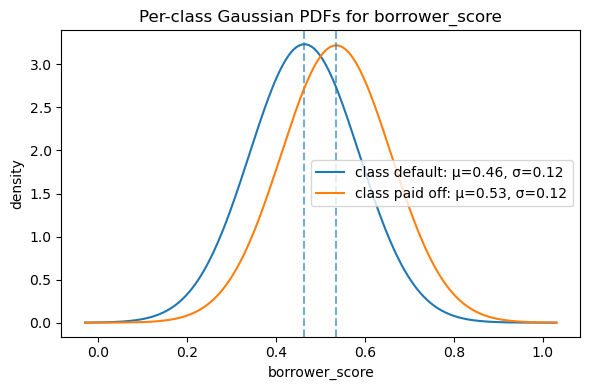

In [2286]:
# classes, mu, sd are already defined from the previous cell:
# classes = gnb.classes_
# mu = means[:, bs_idx]
# sd = np.sqrt(vars_[:, bs_idx])

# Safety: avoid zero-std
eps = 1e-9
sd_safe = np.maximum(sd, eps)

# x-range: cover ±4σ around both means
xmin = float(np.min(mu - 4*sd_safe))
xmax = float(np.max(mu + 4*sd_safe))
x = np.linspace(xmin, xmax, 600)

def gaussian_pdf(x, m, s):
    return (1.0 / (s * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - m) / s)**2)

plt.figure(figsize=(6,4))
for i in range(len(classes)):
    y = gaussian_pdf(x, mu[i], sd_safe[i])
    plt.plot(x, y, label=f"class {classes[i]}: μ={mu[i]:.2f}, σ={sd[i]:.2f}")
    plt.axvline(mu[i], linestyle="--", alpha=0.6)  # show the mean

plt.title("Per-class Gaussian PDFs for borrower_score")
plt.xlabel("borrower_score")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()


<details>
<summary><span style="color:red">What we’re plotting👇</span></summary> 


For each class $c$ (e.g., `default`, `paid off`), we’re plotting the **class-conditional Gaussian density of the single numeric feature `borrower_score`**:

$$
\boxed{\; f_c(x)\;=\;p(\text{borrower\_score}=x \mid y=c)
\;=\;\frac{1}{\sqrt{2\pi}\,\sigma_{c}}
\exp\!\Big(-\tfrac{(x-\mu_{c})^{2}}{2\sigma_{c}^{2}}\Big)\; } 
$$

So each curve is a Normal PDF for `borrower_score` under class $c$.


**Where the numbers come from**  

* `means = gnb.theta_[:, num_idx]` and `vars_ = gnb.var_[:, num_idx]`
  `GaussianNB` estimates a **mean** $\mu_{c,j}$ and **variance** $\sigma^2_{c,j}$ for every class $c$ and every numeric feature $j$ (under the Naive Bayes independence assumption).

* `bs_idx = 0` selects the numeric feature `borrower_score` from `num_cols`.
  Then:

  * `mu = means[:, bs_idx]` gives $[\mu_{c}]_{c}$ for `borrower_score`.
  * `sd = np.sqrt(vars_[:, bs_idx])` gives $[\sigma_{c}]_{c}$.

* `x` is a grid covering both curves:

  $$
  x_{\min}=\min_c(\mu_c-4\sigma_c),\quad
  x_{\max}=\max_c(\mu_c+4\sigma_c),
  $$

  which typically spans \~99.99% of each Normal’s mass.

* In the loop you compute $f_c(x)$ via your `gaussian_pdf` and `plt.plot(x, f_c(x), …)`.
  The dashed `axvline` marks $\mu_c$ for each class.


**What it is **not****

This plot is **not** the posterior $P(y=c\mid x)$.
It only shows the **likelihood** contribution of *one feature* (`borrower_score`) per class.

For Naive Bayes classification with **all** features $x=(x_1,\dots,x_d)$, GaussianNB uses:

$$
\log P(y=c\mid x)\ \propto\ 
\log \pi_c\ +\ \sum_{j=1}^{d}\ \log \mathcal{N}\!\big(x_j\ \big|\ \mu_{c,j},\ \sigma_{c,j}^2\big),
$$

where $\pi_c$ is the class prior and $\mathcal{N}$ is the Gaussian pdf.
Our figure shows only the single-feature term for `borrower_score`:

$$
\log \mathcal{N}\!\big(x_{\text{bs}} \mid \mu_{c,\text{bs}}, \sigma_{c,\text{bs}}^2\big).
$$

**Tiny mental picture**  

* Each curve answers: “**If** the loan is of class $c$, how likely is each `borrower_score` value?”
* Higher peaks and narrower $\sigma_c$ mean the class “expects” scores near $\mu_c$.
* Where the two curves cross is where that feature alone is most ambiguous between classes.

**Notes / gotchas**

* `GaussianNB` also sees our **one-hot categoricals** (from `OneHotEncoder`) as continuous features; we’re just not plotting those.
* Extremely small variances can make densities spike; we mitigated this with `sd_safe = max(sd, 1e-9)`.
* If curves look too “certain,” you can try `GaussianNB(var_smoothing=1e-6)` to inflate tiny variances a touch.

</details>

In [2287]:
# pick a single loan to score (keeps DataFrame shape)
new_loan = X.iloc[[146]]      # or: new_loan = X.sample(1, random_state=0)

# predict class + probabilities
pred = pipe.predict(new_loan)[0]
proba = pipe.predict_proba(new_loan)

# make a nice table with class names as columns
prob_df = pd.DataFrame(proba, columns=pipe.named_steps['clf'].classes_)
prob_df = prob_df.round(6)    

print(f"predicted class:  {pred}")
print("predicted probabilities")
print(prob_df.to_string(index=False))

predicted class:  default
predicted probabilities
 default  paid off
0.999989  0.000011


That super-confident output usually means one (or more) of these is happening because we scored a training row (in-sample → NB gets very sure),

In [2288]:
pre = pipe.named_steps['pre']

# All transformed feature names, in the exact order used by gnb.theta_
feat = pre.get_feature_names_out()

# If you kept the order [('cat', ...), ('num', 'passthrough', ...)],
# the numerics are the LAST len(num_cols) names:
n_num = 14
numeric_names = feat[-n_num:]

print(numeric_names)   

['cat__purpose__credit_card' 'cat__purpose__debt_consolidation'
 'cat__purpose__home_improvement' 'cat__purpose__major_purchase'
 'cat__purpose__medical' 'cat__purpose__other'
 'cat__purpose__small_business' 'cat__home__MORTGAGE' 'cat__home__OWN'
 'cat__home__RENT' 'cat__emp_len__ < 1 Year' 'cat__emp_len__ > 1 Year'
 'num__borrower_score' 'num__payment_inc_ratio']


In [2289]:
X_trans.shape

(45342, 14)

### **Option B: Bin numerics, then use MultinomialNB or CategoricalNB**  
This matches the “bin and convert” suggestion:

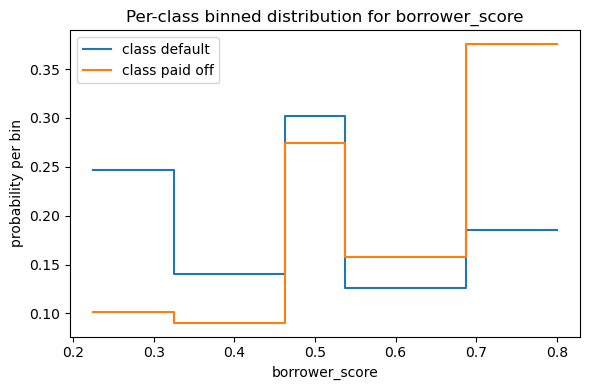

In [2290]:
num_cols = ['borrower_score', 'payment_inc_ratio'] # Names of the numeric features we’ll bin.
cat_cols = ['purpose_', 'home_', 'emp_len_'] # Names of the categorical features we’ll one-hot encode.

prep = ColumnTransformer([
    ('num_bins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])
'''
What if our new data has extra numeric columns not in num_cols?
With our current ColumnTransformer, only the columns you listed are used. Any extra columns in the new DataFrame are ignored (dropped). 
That’s fine and won’t error—as long as the required columns are present.

Builds the preprocessing step:
num_bins: applies KBinsDiscretizer to num_cols.
    n_bins=5: cut each numeric feature into 5 bins.
    encode='onehot-dense': output a dense one-hot matrix (one column per bin).
    strategy='quantile': bins have (approximately) equal counts.
    KBinsDiscretizer doesn’t have (or need) handle_unknown. It learns numeric bin edges during fit, and at transform time every numeric value is put into one of those bins. Values that fall outside the training range are clipped into the first/last bin, so there’s no “unknown” category to handle.
    What you should guard against is missing values in the numeric columns—KBinsDiscretizer won’t accept NaN. If you might have NaNs, add an imputer before binning:
        num_pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('bin', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile')),
        ])

        prep = ColumnTransformer([
            ('num_bins', num_pipe, num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ])
cat: applies OneHotEncoder to cat_cols.
    handle_unknown='ignore': skip unseen categories at predict time (no error).
    sparse_output=False: return dense array.
Output of both parts is concatenated (first num_bins, then cat), forming the final feature matrix.
'''
mnb = MultinomialNB(alpha=0.01) # Creates a Multinomial Naive Bayes classifier with slight Laplace smoothing (alpha=0.01). Works well with nonnegative one-hot/count features.

pipe = Pipeline([('prep', prep), ('clf', mnb)]) # Chains preprocessing and classifier so fit/predict consistently apply prep before clf.


X = loan_data[cat_cols + num_cols]
y = loan_data['outcome']
pipe.fit(X, y)
'''
X = loan_data[cat_cols + num_cols]
Selects the model inputs in a specific column order: all categoricals first, then numerics. (The ColumnTransformer will internally select and reorder by its own tuples.)

y = loan_data['outcome']
Target labels.

pipe.fit(X, y)
Fits the whole pipeline: learns bin edges and one-hot categories, then trains MultinomialNB on the transformed features.
'''

# -------- locate the one-hot bin columns for borrower_score --------
# Inspecting the fitted binning to plot borrower_score’s class distributions:

prep = pipe.named_steps['prep']
#Gets the fitted ColumnTransformer from the pipeline.


disc = prep.named_transformers_['num_bins']            # fitted KBinsDiscretizer
# Pulls the fitted KBinsDiscretizer (the transformer named 'num_bins').

n_bins_arr = disc.n_bins_.astype(int)                  # e.g., [5, 5] for two numeric cols
# Number of bins actually used per numeric feature (array, e.g. [5, 5]).

bs_bins = list(range(0, n_bins_arr[0]))                # borrower_score bins come first
'''
The column indices (within the num_bins block) for borrower_score’s one-hot bins. 
Because ColumnTransformer outputs transformers in order, 
and within num_bins the features are processed in num_cols order, the first n_bins_arr[0] columns correspond to borrower_score.

(For payment_inc_ratio you’d use range(n_bins_arr[0], n_bins_arr[0] + n_bins_arr[1]).)
'''

# bin edges & centers for borrower_score (for plotting on x-axis)
bs_edges = disc.bin_edges_[0]                          # array of length n_bins+1.    # array([0.05, 0.4 , 0.45, 0.55, 0.6 , 1.  ])
bs_centers = 0.5 * (bs_edges[:-1] + bs_edges[1:])      # length n_bins.  # array([0.225, 0.425, 0.5  , 0.575, 0.8  ])

# -------- get per-class probabilities for those bins --------
# Get per-class probabilities over the borrower_score bins

clf = pipe.named_steps['clf']   # The fitted MultinomialNB.
# Pulls the trained MultinomialNB out of the pipeline so we can inspect its learned parameters.

classes = clf.classes_    # array(['default', 'paid off'], dtype='<U8')

# MultinomialNB.feature_log_prob_: shape [n_classes, n_features(one-hot)]
# Extract the columns corresponding to borrower_score's bins
logp_bs = clf.feature_log_prob_[:, bs_bins]            # [n_classes, n_bins] (2,5)
'''
array([[-3.00954535, -3.57647628, -2.80671437, -3.68285311, -3.29258646],
       [-3.89587534, -4.01121942, -2.90339821, -3.45320744, -2.58916581]])
feature_log_prob_ has shape [n_classes, n_features_after_transform] and sums to 1 across all features per class. 
Here we slice only the columns belonging to borrower_score’s bins → [n_classes, n_bins_for_bs].
'''

p_bs = np.exp(logp_bs) # Convert log-probs to probs.

# Renormalize within the group so bins sum to 1 per class (for a proper per-feature PMF)
p_bs = p_bs / p_bs.sum(axis=1, keepdims=True)
'''
array([[0.24657041, 0.13987045, 0.30201557, 0.12575553, 0.18578804],
       [0.10162785, 0.09055646, 0.27418271, 0.15821984, 0.37541314]])
''' 

# -------- plot: per-class PMF over borrower_score bins --------
# Creates a step plot of the per-class probability mass over borrower_score’s bins, using bin centers on the x-axis and the normalized bin probabilities on the y-axis.
plt.figure(figsize=(6,4))
for i, c in enumerate(classes):
    # step plot over bin centers; you can switch to bars if you prefer
    plt.step(bs_centers, p_bs[i], where='mid', label=f"class {c}")
    # optional: draw bin edges as vertical dotted lines
    # for e in bs_edges: plt.axvline(e, color='k', alpha=0.1, linewidth=1)

plt.title("Per-class binned distribution for borrower_score")
plt.xlabel("borrower_score")
plt.ylabel("probability per bin")
plt.legend()
plt.tight_layout()
plt.show()


<details>
<summary><span style="color:red">What we’re plotting👇</span></summary> 


We are plotting, for each class $c$, the probability that `borrower_score` falls into each bin.
In symbols:

$$
\boxed{ \;p_{\text{bs}}(k \mid y=c)\; } \qquad \text{(a probability for each bin $k$)}.
$$

This is a likelihood for that one feature (`borrower_score`), not the overall posterior $P(y \mid x)$.

**Where those numbers come from in your code**  

`MultinomialNB` learns one big probability vector per class.  
After fitting, scikit-learn gives:

$$\theta_{c,m} \quad\text{for } m=1,\ldots ,M$$

where each $m$ is one one-hot column (every bin of every numeric feature + every category of every categorical feature).  
They satisfy $\sum_{m=1}^M \theta_{c,m}=1$ for each class $c$.

In code: `clf.feature_log_prob_[c, m] = log(θ_{c,m})`.

We extract just the columns belonging to `borrower_score`’s bins.  
Let those column indices be `bs_bins = [m(bs,1), …, m(bs,K)]`.

In code:
```python
logp_bs = clf.feature_log_prob_[:, bs_bins]     # log θ_{c, m(bs,k)}
p_bs_raw = np.exp(logp_bs)                      # θ_{c, m(bs,k)}
```

Because $\theta_{c,m}$ sums to 1 over *all* features, we re-normalize within this group to get a proper distribution over just the `borrower_score` bins:

$$
\boxed{\; p_{\text{bs}}(k \mid y=c) = \frac{\theta_{c, m(\text{bs},k)}}{\sum_{k'=1}^{K} \theta_{c, m(\text{bs},k')}}\; }
$$

In code:

```python
p_bs = p_bs_raw / p_bs_raw.sum(axis=1, keepdims=True)
```

We plot these $p_{\text{bs}}(k \mid y=c)$ values at the bin centers.
That’s why the y-axis label is “probability per bin”.

**What it is not**  

It is not the classifier’s posterior:

$$
\log P(y=c \mid x) \propto \underbrace{\log \pi_c}_{\text{class\_log\_prior\_}} \;+\; \sum_{\text{feature groups }g} \underbrace{\log \theta_{c, m(g, k_g)}}_{\text{pick the active bin/category in each group}}.
$$

That posterior uses:
- the prior $\pi_c$ and
- one term per feature group (your chosen bin/category in every group).

Our plot only shows one group’s likelihood $p_{\text{bs}}(k\mid y=c)$.

**Tiny mental picture**  

Think of all one-hot columns as one long vocabulary.  
$\theta_{c,m} = $ “chance of picking column $m$ if you’re in class $c$”.  
You’re asking: “Within just the `borrower_score` part of that vocabulary, how do those chances distribute across its $K$ bins?”

$\Rightarrow$ Slice those $K$ columns and renormalize them to sum to 1.  
$\Rightarrow$ Plot the result.

</details>

In [2291]:
p_bs

array([[0.24657041, 0.13987045, 0.30201557, 0.12575553, 0.18578804],
       [0.10162785, 0.09055646, 0.27418271, 0.15821984, 0.37541314]])

In [2292]:
# pick a single loan to score (keeps DataFrame shape)
new_loan = X.iloc[[146]]      # or: new_loan = X.sample(1, random_state=0)

# predict class + probabilities
pred = pipe.predict(new_loan)[0]
proba = pipe.predict_proba(new_loan)

# make a nice table with class names as columns
prob_df = pd.DataFrame(proba, columns=pipe.named_steps['clf'].classes_)
prob_df = prob_df.round(6)    # to match your example formatting

print(f"predicted class:  {pred}")
print("predicted probabilities")
print(prob_df.to_string(index=False))


predicted class:  default
predicted probabilities
 default  paid off
 0.50228   0.49772


In [2293]:
# show transformed features (design matrix) as a DataFrame with column names
pipe.set_output(transform='pandas')        # makes transformers return DataFrames
design = pipe[:-1].transform(X)            # run only the preprocessing step(s)
design.head()                              # first 5 rows


,num_bins__borrower_score_0.0,num_bins__borrower_score_1.0,num_bins__borrower_score_2.0,num_bins__borrower_score_3.0,num_bins__borrower_score_4.0,num_bins__payment_inc_ratio_0.0,num_bins__payment_inc_ratio_1.0,num_bins__payment_inc_ratio_2.0,num_bins__payment_inc_ratio_3.0,num_bins__payment_inc_ratio_4.0,...,cat__purpose__home_improvement,cat__purpose__major_purchase,cat__purpose__medical,cat__purpose__other,cat__purpose__small_business,cat__home__MORTGAGE,cat__home__OWN,cat__home__RENT,cat__emp_len__ < 1 Year,cat__emp_len__ > 1 Year
0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


**Why `MultinomialNB` here?**

Our preprocessing makes one-hot features for both numeric (via `KBins`) and categorical columns.

`MultinomialNB` naturally handles one-hot count-like inputs.

`CategoricalNB` expects each feature to be a single integer category (not one-hot). If you really want CategoricalNB, switch to ordinal encoding:
```python
Correct CategoricalNB alternative (no one-hot):

from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer
from sklearn.naive_bayes import CategoricalNB

pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('num_bins', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), num_cols),
        ('cat_ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ])),
    ('clf', CategoricalNB(alpha=1.0))
])
```

Then we’d read per-class bin/category probabilities from clf.category_count_ (counts per feature/category/class) and normalize them for plotting.

Pick whichever aligns with your goal—one-hot + MultinomialNB is the closest drop-in to what you already wrote.

In [2294]:
loan_data[num_cols].nunique()
loan_data[num_cols].describe()


,borrower_score,payment_inc_ratio
count,45342.000000,45342.000000
mean,0.499006,8.032225
std,0.128687,4.264034
min,0.050000,0.048892
25%,0.400000,4.671572
50%,0.500000,7.499355
75%,0.600000,10.940575
max,1.000000,43.545600


- `CategoricalNB` expects categorical/discrete features; binning makes numeric features discrete.  
- `MultinomialNB` also works on the one-hot counts this creates.

**Which should you choose?**  
- If you want to preserve numeric information and assume Gaussian per class (like your R example): **Option A** (GaussianNB).  
- If you prefer a purely discrete/categorical model (or want compatibility with MultinomialNB): **Option B** (bin + CategoricalNB/MultinomialNB).  

*Note:* The statement “Numerical variables are not supported in scikit-learn” refers specifically to MultinomialNB/BernoulliNB. GaussianNB supports numeric features directly by modeling them as normal.  

**Bonus: calibrated probabilities** (if you care about well-calibrated $P(Y=1 \mid x)$)  
Naive Bayes often yields biased probabilities. You can wrap the pipeline with probability calibration:

In [2295]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(pipe, method='isotonic', cv=5)
calibrated.fit(loan_data[cat_cols + num_cols], loan_data['outcome']);

This keeps your ranking but improves probability calibration when you need thresholds/costing.

## **Discriminant Analysis**  

### **A Simple Example**

In [2296]:
loan3000 = pd.read_csv(LOAN3000_CSV)
loan3000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         3000 non-null   int64  
 1   outcome            3000 non-null   object 
 2   purpose_           3000 non-null   object 
 3   dti                3000 non-null   float64
 4   borrower_score     3000 non-null   float64
 5   payment_inc_ratio  3000 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 140.8+ KB


In [2297]:
loan3000['outcome'] = loan3000['outcome'].astype('category')
loan3000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Unnamed: 0         3000 non-null   int64   
 1   outcome            3000 non-null   category
 2   purpose_           3000 non-null   object  
 3   dti                3000 non-null   float64 
 4   borrower_score     3000 non-null   float64 
 5   payment_inc_ratio  3000 non-null   float64 
dtypes: category(1), float64(3), int64(1), object(1)
memory usage: 120.4+ KB


In [2298]:
loan3000['outcome'] = loan3000['outcome'].astype('category') # Stores the target column as a pandas categorical type (labels/classes). Scikit-learn will treat each category as a class.

predictors = ['borrower_score', 'payment_inc_ratio'] # continuous numeric variables. 
outcome = 'outcome'

X = loan3000[predictors] # Feature matrix with the two columns (shape: n_samples × 2).
y = loan3000[outcome] # Class labels (Series of categories).

loan_lda = LinearDiscriminantAnalysis() # Creates an LDA model (default solver='svd').
'''
default solver='svd' means: if you create LinearDiscriminantAnalysis() without options, scikit-learn uses the SVD (singular value decomposition) algorithm to fit LDA.
What SVD solver does:
    Uses an SVD of the (centered) design matrix to find the discriminant directions without inverting a covariance matrix (good when features are collinear or p>n).
    Numerically stable and fast; that’s why it’s the default.
'''
loan_lda.fit(X, y) # Fits LDA: estimates class means and the pooled covariance, then finds the Fisher discriminant direction(s) that best separate classes.
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))
'''
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))
Prints the loadings/weights of the linear discriminant(s).

- loan_lda.scalings_ has shape (n_features, n_components).
- With binary y, n_components = 1, so you’ll see a single column: the weight for borrower_score and the weight for payment_inc_ratio.
- This vector w defines the discriminant score d(x) = w^T x.
  Larger d(x) favors one class; smaller favors the other.

How to interpret the numbers:
- Sign is arbitrary (flipping all signs gives the same separation).
  Focus on relative magnitude: bigger |w_j| ⇒ feature j contributes more to the separation given the covariance structure.

- Units matter: LDA isn’t scale-invariant; if predictors have very different scales,
  consider standardizing before fitting if you want weights to be directly comparable.

(Optional) See scores and posteriors:
  scores = loan_lda.decision_function(X)   # 1D array: discriminant scores
  proba  = loan_lda.predict_proba(X)       # posterior class probabilities
'''

                          0
borrower_score     7.175839
payment_inc_ratio -0.099676


'\nprint(pd.DataFrame(loan_lda.scalings_, index=X.columns))\nPrints the loadings/weights of the linear discriminant(s).\n\n- loan_lda.scalings_ has shape (n_features, n_components).\n- With binary y, n_components = 1, so you’ll see a single column: the weight for borrower_score and the weight for payment_inc_ratio.\n- This vector w defines the discriminant score d(x) = w^T x.\n  Larger d(x) favors one class; smaller favors the other.\n\nHow to interpret the numbers:\n- Sign is arbitrary (flipping all signs gives the same separation).\n  Focus on relative magnitude: bigger |w_j| ⇒ feature j contributes more to the separation given the covariance structure.\n\n- Units matter: LDA isn’t scale-invariant; if predictors have very different scales,\n  consider standardizing before fitting if you want weights to be directly comparable.\n\n(Optional) See scores and posteriors:\n  scores = loan_lda.decision_function(X)   # 1D array: discriminant scores\n  proba  = loan_lda.predict_proba(X)      

In [2299]:
i = loan_lda.decision_function(X) #z
i

array([-0.21499928, -0.23691565,  0.98098577, ..., -1.9056891 ,
       -0.22953286, -0.74669527], shape=(3000,))

In [2300]:
loan_lda.predict_proba(X) # P(y=1 | x) = 1/ (1 + e^{-z}) "default" and P(y=0 | x) = 1 - P(y=1 | x) "paid off"
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


In [2301]:
print(loan_lda.coef_) # [[ 4.92601223 -0.0684245 ]]
print(loan_lda.intercept_)

[[ 4.92601223 -0.0684245 ]]
[-1.83566262]


In [2302]:
print(loan_lda.scalings_) 
# [[ 7.1758388 ]
#  [-0.09967559]]

[[ 7.1758388 ]
 [-0.09967559]]


In [2303]:
w = loan_lda.coef_.ravel()        # [ 4.92601223, -0.0684245 ]
v = loan_lda.scalings_.ravel()    # [ 7.1758388 , -0.09967559]
w / v
# => [0.68647197, 0.68647197]  ~ constant scale s
# So they point in the same direction; one is just a scaled version of the other. 
# The intercept is scaled accordingly so predictions/probabilities stay identical.

# scalings_: projection axis (Fisher direction), arbitrary scale/sign.
# coef_: the actual decision weights used with an intercept.
# In binary LDA they’re proportional; differences are just a constant factor (and possibly a global sign flip).

array([0.68647197, 0.68647197])

<details>
<summary><span style="color:red">Read more👇</span></summary> 

Suppose our `scalings_` prints like this:

|                   | LD1   |
|-------------------|--------|
| borrower_score    | 1.25   |
| payment_inc_ratio | -0.40  |

This means the linear discriminant direction (a 2-vector) is  
$$ w = \begin{bmatrix} 1.25 \\ -0.40 \end{bmatrix} $$

**Discriminant score for a loan $x$**  

For any loan with features  
$$ x = [\text{borrower\_score},\, \text{payment\_inc\_ratio}]^\top $$

the discriminant score is the 1-D projection:

$$
d(x) = w^\top x = 1.25 \cdot \text{borrower\_score} - 0.40 \cdot \text{payment\_inc\_ratio}
$$

**Example loans**  

- Loan A: borrower_score = 0.62, payment_inc_ratio = 0.15  
  $$ d(A) = 1.25(0.62) - 0.40(0.15) = 0.775 - 0.060 = 0.715 $$

- Loan B: borrower_score = 0.48, payment_inc_ratio = 0.28  
  $$ d(B) = 1.25(0.48) - 0.40(0.28) = 0.600 - 0.112 = 0.488 $$

- Loan C: borrower_score = 0.10, payment_inc_ratio = 1.20  
  $$ d(C) = 1.25(0.10) - 0.40(1.20) = 0.125 - 0.480 = -0.355 $$

**Interpretation (intuitive)**  

- Higher borrower_score pushes $d(x)$ up (because +1.25)
- Higher payment_inc_ratio pushes $d(x)$ down (because −0.40)

**How does this become a class prediction?**  

LDA uses a linear decision rule:

- Predict class 1 if $$ w^\top x + b > 0 $$
- Otherwise, class 0

The constant $b$ (the intercept) comes from class means, the pooled covariance, and class priors.  
In scikit-learn, you can see it with:  
`loan_lda.coef_`, `loan_lda.intercept_`.

- `coef_` is the actual decision weights used with the intercept.  
- `scalings_` are the discriminant directions (the axis you project onto).  
- In the binary case they point in the same separating direction; signs can flip without changing predictions.

**Example with intercept $b = -0.50$ (illustration)**  

- For Loan A: $$ 0.715 - 0.50 = 0.215 > 0 $$ → predict class 1  
- For Loan B: $$ 0.488 - 0.50 = -0.012 < 0 $$ → predict class 0 (borderline)  
- For Loan C: $$ -0.355 - 0.50 = -0.855 < 0 $$ → predict class 0  

**What the magnitudes mean**  

$$ |1.25| > |0.40| $$

Within LDA’s covariance weighting, borrower_score contributes more to separation than payment_inc_ratio.

Sign is arbitrary as a global flip (both weights and $b$ can flip sign and predictions stay the same). Focus on relative size.

**LDA is not scale-invariant**  

If features have very different units, standardize first if you want weights to be directly comparable.

**Optional: a peek under the hood**  

For two classes with common covariance $\Sigma$ and means $\mu_0, \mu_1$, the theoretical discriminant direction is

$$
w \propto \Sigma^{-1}(\mu_1 - \mu_0), \quad b = \log \frac{\pi_1}{\pi_0} - \frac{1}{2} (\mu_1 + \mu_0)^\top \Sigma^{-1} (\mu_1 - \mu_0),
$$

where $\pi_c$ are class priors. scikit-learn’s `coef_`/`intercept_` implement this (up to a common scaling), while `scalings_` gives the projection axis (“LD1”) you plotted or can use for 1-D visualization.

**Binary LDA and predicting probabilities**  

You can get `predict_proba` directly from the 1-D `decision_function` by passing it through a logistic (sigmoid) function:

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-z}} \quad \text{and} \quad P(y=0 \mid x) = 1 - P(y=1 \mid x)
$$

where

$$
z = \delta_1(x) - \delta_0(x) = w^\top x + b
$$

**Quick math why this works**  

LDA computes one linear “score” per class, $\delta_0(x)$ and $\delta_1(x)$.  
Posterior probabilities are a softmax over these scores:

$$
P(y = c \mid x) = \frac{e^{\delta_c(x)}}{e^{\delta_0(x)} + e^{\delta_1(x)}}
$$

The binary decision function returns

$$
z = \delta_1(x) - \delta_0(x),
$$

which is then transformed by the sigmoid to get probabilities.  

In LDA, $\delta_0(x)$ is the discriminant score for class 0.  
It’s a linear function of the features $x$ that combines the class-0 mean, the (pooled) covariance, and the class prior:

$$
\boxed{
\delta_c(x) = x^\top \Sigma^{-1} \mu_c - \tfrac{1}{2} \mu_c^\top \Sigma^{-1} \mu_c + \log \pi_c
}
$$

where  
- $\mu_c$: mean vector of class $c$  
- $\Sigma$: pooled within-class covariance matrix (assumed common across classes)  
- $\pi_c$: prior probability of class $c$  

Equivalent form (showing the Mahalanobis distance; constants dropped):

$$
\delta_c(x) = -\tfrac{1}{2} (x - \mu_c)^\top \Sigma^{-1} (x - \mu_c) + \log \pi_c + \text{const}
$$

You predict the class with the largest $\delta_c(x)$.

**Binary case and link to decision_function**  

For two classes (0 and 1), scikit-learn’s `decision_function(X)` returns

$$
z = \delta_1(x) - \delta_0(x) = (\mu_1 - \mu_0)^\top \Sigma^{-1} x - \tfrac{1}{2} \big(\mu_1^\top \Sigma^{-1} \mu_1 - \mu_0^\top \Sigma^{-1} \mu_0\big) + \log \frac{\pi_1}{\pi_0}
$$

This is a linear score

$$
z = w^\top x + b
$$

with

$$
w = \Sigma^{-1}(\mu_1 - \mu_0), \quad b = -\tfrac{1}{2}(\mu_1^\top \Sigma^{-1} \mu_1 - \mu_0^\top \Sigma^{-1} \mu_0) + \log \frac{\pi_1}{\pi_0}
$$

Then the posterior probability comes from the logistic function:

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-z}}, \quad P(y=0 \mid x) = 1 - P(y=1 \mid x)
$$

$\delta_0(x)$ itself is not a probability — it’s the class-0 score used in this comparison; the difference $\delta_1(x) - \delta_0(x)$ is what your `decision_function` reports (up to a common scaling), and from it you get `predict_proba` via the sigmoid.

</details>

In [2304]:
type(X)

pandas.core.frame.DataFrame

## **Figure 5.1**

In [2305]:
classes

array(['default', 'paid off'], dtype='<U8')

In [2306]:
list(classes).index('default')

0

In [2307]:
loan_lda.intercept_

array([-1.83566262])

In [2308]:
loan_lda.coef_[0] 

array([ 4.92601223, -0.0684245 ])

In [2309]:
X

,borrower_score,payment_inc_ratio
0,0.40,5.11135
1,0.40,5.43165
2,0.70,9.23003
3,0.40,2.33482
4,0.45,12.10320
...,...,...
2995,0.50,18.36620
2996,0.60,1.80421
2997,0.20,15.42180
2998,0.45,8.92335


In [2310]:
loan_lda.means_

array([[0.46280277, 8.86181347],
       [0.53906752, 7.4651989 ]])

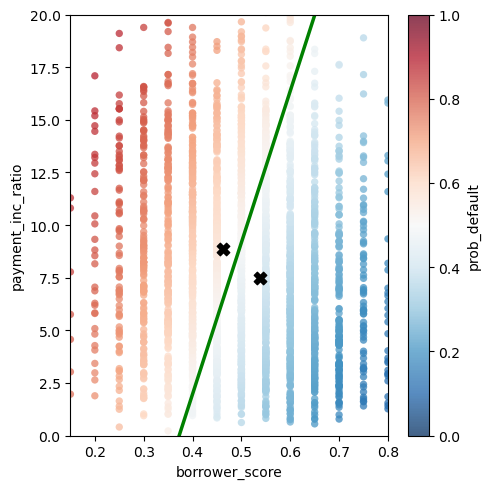

In [2311]:
# 1) Probabilities for default
proba = loan_lda.predict_proba(X)
classes = loan_lda.classes_
try:
    idx_default = list(classes).index('default')
except ValueError:
    # fallback: assume the 1st class is the "positive" class
    idx_default = 0

plot_df = loan3000.copy()
plot_df['prob_default'] = proba[:, idx_default]

# 2) Decision boundary from the actual classifier (w^T x + b = 0)
w = loan_lda.coef_[0]          # [w_bs, w_pir]
b = loan_lda.intercept_[0]
# y = m*x + c  where m = -w_bs/w_pir and c = -b/w_pir
m = -w[0] / w[1]
c = -b / w[1]

# endpoints at y=0 and y=20 (your axis limits)
y0, y1 = 0.0, 20.0
x0 = (y0 - c) / m
x1 = (y1 - c) / m

# 3) Plot
fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter(
    plot_df['borrower_score'],
    plot_df['payment_inc_ratio'],
    c=plot_df['prob_default'], #A 1-D array of values (same length as x/y) used to color each point by a colormap. Higher/lower values map to different colors.
    cmap='RdBu_r', vmin=0.0, vmax=1.0,
    s=28, alpha=0.75, linewidths=0
)

# green decision boundary
ax.plot([x0, x1], [y0, y1], color='green', linewidth=2.5)

# class means
ax.scatter(loan_lda.means_[:, 0], loan_lda.means_[:, 1],
           c='black', s=80, marker='X')

# axes & labels
ax.set_xlim(0.15, 0.80)
ax.set_ylim(0.0, 20.0)
ax.set_xlabel('borrower_score')
ax.set_ylabel('payment_inc_ratio')

# continuous colorbar for prob_default
cb = plt.colorbar(sc, ax=ax)
cb.set_label('prob_default')

plt.tight_layout()
plt.show()


## **Logistic regression**  

### **Logistic Response Function and Logit**

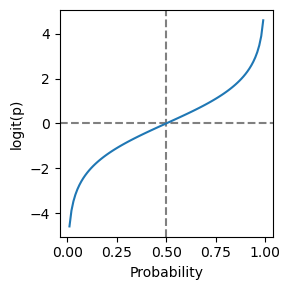

In [2312]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    'p': p,
    'logit': np.log(p / (1 - p)),
    'odds': p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit'])
ax.set_xlabel('Probability')
ax.set_ylabel('logit(p)')

plt.tight_layout()
plt.show()

In [2313]:
df

,p,logit,odds
0,0.01,-4.595120,0.010101
1,0.02,-3.891820,0.020408
2,0.03,-3.476099,0.030928
3,0.04,-3.178054,0.041667
4,0.05,-2.944439,0.052632
...,...,...,...
94,0.95,2.944439,19.000000
95,0.96,3.178054,24.000000
96,0.97,3.476099,32.333333
97,0.98,3.891820,49.000000


## **Logistic Regression and the GLM**  

The package scikit-learn has a specialised class for `LogisticRegression`. Statsmodels has a more general method based on generalized linear model (GLM).


In [2314]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'
predictors

['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'borrower_score']

In [2315]:
loan_data[predictors + [outcome]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   payment_inc_ratio  45342 non-null  float64 
 1   purpose_           45342 non-null  category
 2   home_              45342 non-null  category
 3   emp_len_           45342 non-null  category
 4   borrower_score     45342 non-null  float64 
 5   outcome            45342 non-null  category
dtypes: category(4), float64(2)
memory usage: 886.4 KB


In [2316]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
'''
pd.get_dummies automatically looks at all columns you pass in (loan_data[predictors]):
    If you explicitly convert something to category, it will definitely be one-hot encoded.
    If it’s already of type object (like string labels), it will also be one-hot encoded.
    If it’s numeric (int/float), it’s left as-is.
    The order of columns in X after:
    X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
    is determined by pandas’ default behavior for get_dummies:
    For each predictor (purpose_, home_, emp_len_), pandas looks at the unique categories in that column.
    Within each column, the dummy columns are created in sorted (alphabetical / ascending numeric) order of the category labels. 
    Example: if home_ has categories [MORTGAGE, OWN, RENT], the dummies will appear in this order:
    MORTGAGE, OWN, RENT
    Across predictors, pandas processes them in the order you gave (predictors = ['purpose_', 'home_', 'emp_len_']).
    So first you’ll see all dummy columns for purpose_, then for home_, then for emp_len_.
    dtype=int makes them integers instead of booleans.
    prefix='' and prefix_sep='' keep clean column names (no extra prefixes like home__RENT).
'''
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
'''
Model is fit with LogisticRegression, using essentially no regularization (C=1e42).
solver='liblinear' means scikit-learn is calling the LIBLINEAR library to solve the logistic regression optimization, 
using coordinate descent — best for small to medium datasets and compatible with both L1 and L2 penalties.
'''
logit_reg.fit(X, y) # scikit-learn will encode y internally into [0,1].
'''
One-hot encode predictors (X), not the outcome (y).
For binary logistic regression in sklearn, keep y as a 1D vector (numeric or string labels).
One-hot encoding of y is only needed in some ML frameworks (e.g., TensorFlow, PyTorch), not here.
'''

# Prints intercept, class labels, and a DataFrame of coefficients matched to column names:
print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]}, 
             index=X.columns)

intercept  -1.6380885706304693
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079728
borrower_score,4.611037
debt_consolidation,-0.249342
home_improvement,-0.407614
major_purchase,-0.229376
medical,-0.510087
other,-0.620534
small_business,-1.215662
OWN,-0.048453
RENT,-0.157355


In [2317]:
y

0         default
1         default
2         default
3         default
4         default
           ...   
45337    paid off
45338    paid off
45339    paid off
45340    paid off
45341    paid off
Name: outcome, Length: 45342, dtype: category
Categories (2, object): ['default', 'paid off']

In [2318]:
X.iloc[[14666]]

,payment_inc_ratio,borrower_score,debt_consolidation,home_improvement,major_purchase,medical,other,small_business,OWN,RENT,> 1 Year
14666,9.9992,0.3,1,0,0,0,0,0,1,0,1


In [2319]:
new_record =  X.iloc[[14666]]
pd.DataFrame(logit_reg.predict_proba(new_record), columns=logit_reg.classes_)

,default,paid off
0,0.729548,0.270452


In [2320]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45342 entries, 0 to 45341
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   payment_inc_ratio   45342 non-null  float64
 1   borrower_score      45342 non-null  float64
 2   debt_consolidation  45342 non-null  int64  
 3   home_improvement    45342 non-null  int64  
 4   major_purchase      45342 non-null  int64  
 5   medical             45342 non-null  int64  
 6   other               45342 non-null  int64  
 7   small_business      45342 non-null  int64  
 8   OWN                 45342 non-null  int64  
 9   RENT                45342 non-null  int64  
 10   > 1 Year           45342 non-null  int64  
dtypes: float64(2), int64(9)
memory usage: 3.8 MB


In [2321]:
print(loan_data['purpose_'].cat.categories) # .cat.categories returns the Index of all unique categories (levels) that this column can take.
'''
Use .unique() if you just want to see what values appear in this dataset.
Use .cat.categories if you need the full set of categories defined (important for consistent encoding in ML).
'''
print(loan_data['home_'].cat.categories)
print(loan_data['emp_len_'].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='object')
Index([' < 1 Year', ' > 1 Year'], dtype='object')


In [2322]:
loan_data['purpose_'].unique()

['major_purchase', 'small_business', 'other', 'debt_consolidation', 'credit_card', 'home_improvement', 'medical']
Categories (7, object): ['credit_card', 'debt_consolidation', 'home_improvement', 'major_purchase', 'medical', 'other', 'small_business']

Not in book : If you have a feature or outcome variable that is ordinal, use the scikit-learn `OrdinalEncoder` to replace the categories (here, 'paid off' and 'default') with numbers. In the below code, we replace 'paid off' with 0 and 'default' with 1. This reverses the order of the predicted classes and as a consequence, the coefficients will be reversed.


In [2323]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off', 'default']])
'''
OrdinalEncoder converts categorical values into integer codes.
By passing categories=[['paid off', 'default']], you explicitly fix the mapping:
    "paid off" → 0
    "default" → 1
fit_transform returns a 2D array, but .ravel() flattens it into a 1D array (required for y).
So now your target y_enc is numeric (0 and 1), which LogisticRegression expects.
'''
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel() 
# .fit_transform = learn the encoding rules and apply them to your data in one step. 
# ravel(): flattens the result from a 2D array (shape (n_samples, 1)) into a 1D array (shape (n_samples,)), which is required for LogisticRegression.fit().
'''
fit_transform(...)
fit: looks at the outcome column (with values like "paid off", "default") and learns the mapping you provided ("paid off" → 0, "default" → 1).
transform: applies that mapping to each row in loan_data[[outcome]].
.ravel(): flattens the result from a 2D array (shape (n_samples, 1)) into a 1D array (shape (n_samples,)), which is required for LogisticRegression.fit().
'''
logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]},   index=X.columns)

intercept  1.6378908629195823
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
debt_consolidation,0.249414
home_improvement,0.407734
major_purchase,0.229710
medical,0.510744
other,0.620800
small_business,1.214936
OWN,0.048211
RENT,0.157288


Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')

## **Predicted Values from Logistic Regression**

In [2324]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean      -0.757850     -0.760423
std        0.378032      0.390419
min       -2.768873     -3.538865
25%       -0.985728     -0.977164
50%       -0.697366     -0.688946
75%       -0.472209     -0.467076
max       -0.029476     -0.064787


In [2325]:
pred = pd.DataFrame(logit_reg_enc.predict_log_proba(X),
                    columns=logit_reg_enc.classes_)
print(pred.describe())
# "paid off" → 0    "default" → 1

                0.0           1.0
count  45342.000000  45342.000000
mean      -0.760434     -0.757872
std        0.390456      0.378093
min       -3.538593     -2.769376
25%       -0.977207     -0.985739
50%       -0.688907     -0.697406
75%       -0.467069     -0.472183
max       -0.064753     -0.029485


In [2326]:
pred

,0.0,1.0
0,-0.277739,-1.416731
1,-0.377043,-1.158001
2,-0.727014,-0.660390
3,-0.886754,-0.531013
4,-0.613669,-0.779492
...,...,...
45337,-0.792219,-0.603012
45338,-0.621530,-0.770292
45339,-0.593639,-0.803663
45340,-0.326151,-1.279041


In [2327]:
pred = pd.DataFrame(logit_reg.predict_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean       0.500001      0.499999
std        0.167336      0.167336
min        0.062733      0.029046
25%        0.373167      0.376377
50%        0.497895      0.502105
75%        0.623623      0.626833
max        0.970954      0.937267


In [2328]:
pred

,default,paid off
0,0.242502,0.757498
1,0.314407,0.685593
2,0.516627,0.483373
3,0.588000,0.412000
4,0.458618,0.541382
...,...,...
45337,0.547148,0.452852
45338,0.462828,0.537172
45339,0.447681,0.552319
45340,0.278330,0.721670


## **Interpreting the Coefficients and Odds Ratios**

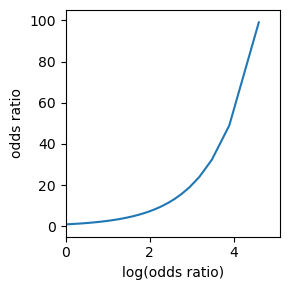

In [2329]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)')
ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

In [2330]:
y

0         default
1         default
2         default
3         default
4         default
           ...   
45337    paid off
45338    paid off
45339    paid off
45340    paid off
45341    paid off
Name: outcome, Length: 45342, dtype: category
Categories (2, object): ['default', 'paid off']

In [2331]:
X.head()

,payment_inc_ratio,borrower_score,debt_consolidation,home_improvement,major_purchase,medical,other,small_business,OWN,RENT,> 1 Year
0,2.39320,0.65,0,0,1,0,0,0,0,1,1
1,4.57170,0.80,0,0,0,0,0,1,1,0,1
2,9.71600,0.60,0,0,0,0,1,0,0,1,1
3,12.21520,0.50,1,0,0,0,0,0,0,1,1
4,3.90888,0.55,0,0,0,0,1,0,0,1,1


## **Assessing the Model**  

For comparison, here the GLM model using statsmodels. This method requires that the outcome is mapped to numbers.

In [2332]:
# use GLM (general linear model) with the binomial family to 
# fit a logistic regression
y_numbers = [1 if yi == 'default' else 0 for yi in y] # This choice fixes the interpretation: positive coefficients → higher odds of default.
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1), 
                      family=sm.families.Binomial())
'''
Builds a generalized linear model with a Binomial family.
For Binomial, the default link is logit, so the model is logistic regression:
  Pr(Y=1 | x) = 1 / (1 + exp(-η)),   where   η = β0 + β^T x
X.assign(const=1) adds an intercept column named 'const'(statsmodels doesn’t add it automatically unless you use the formula API):

# If your target column is named `outcome` with values 'default' / 'paid off':
loan_data["y"] = (loan_data["outcome"] == "default").astype(int)

# Recommended: use the raw categoricals with C()
formula = (
    "y ~ payment_inc_ratio + borrower_score "
    "+ C(purpose_) + C(home_) + C(emp_len_)"
)
# If purpose_, home_ownership, time_in_emp are string or pandas category dtype:
Patsy/statsmodels will automatically treat them as categorical even without C(). You’ll get treatment (reference) coding with k−1 dummies, baseline = the first level (by category order; if unordered, usually alphabetical).

model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial()) # The intercept is included by default, that's why our results table shows an intercept row.
result = model.fit()
print(result.summary())
'''
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Thu, 25 Sep 2025   Deviance:                       57515.
Time:                        21:35:06   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

The last two columns specify the a 95% CI: A 95% CI means that if you repeated the entire data-collection and fitting procedure many times, and each time built an interval the same way, about 95% of those intervals would contain the true coefficient (assuming the model is correct).

In [2333]:
import statsmodels.formula.api as smf
formula = ('outcome ~ bs(payment_inc_ratio, df=4) + purpose_ + ' +
'home_ + emp_len_ + bs(borrower_score, df=4)')

# bs() = B-spline basis; cr() = natural cubic spline. 
# Coefficients of basis functions aren’t directly meaningful; plot predicted curve for interpretation.
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45324
Model Family:                                       Binomial   Df Model:                           17
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28744.
Date:                                       Thu, 25 Sep 2025   Deviance:                       57487.
Time:                                               21:35:06   Pearson chi2:                 4.54e+04
No. Iterations:                                            5   Pseudo R-squ. (CS):             0.1117
Covariance Type:                                   nonrobust                      

In [2334]:
formula = ('outcome ~ bs(payment_inc_ratio, df=3) + purpose_ + ' +
           'home_ + emp_len_ + bs(borrower_score, df=3)')
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45326
Model Family:                                       Binomial   Df Model:                           15
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28745.
Date:                                       Thu, 25 Sep 2025   Deviance:                       57490.
Time:                                               21:35:06   Pearson chi2:                 4.54e+04
No. Iterations:                                            5   Pseudo R-squ. (CS):             0.1116
Covariance Type:                                   nonrobust                      

In [2335]:
i = results.params.copy()
i.shape
type(i)
i.iloc[3]
print(i)

Intercept                         1.991893
purpose_[T.debt_consolidation]    0.249162
purpose_[T.home_improvement]      0.414433
purpose_[T.major_purchase]        0.240998
purpose_[T.medical]               0.522083
purpose_[T.other]                 0.631894
purpose_[T.small_business]        1.224256
home_[T.OWN]                      0.048427
home_[T.RENT]                     0.157757
emp_len_[T. > 1 Year]            -0.354288
bs(payment_inc_ratio, df=3)[0]    1.028306
bs(payment_inc_ratio, df=3)[1]    3.669892
bs(payment_inc_ratio, df=3)[2]   -2.573037
bs(borrower_score, df=3)[0]      -2.904978
bs(borrower_score, df=3)[1]      -2.604971
bs(borrower_score, df=3)[2]      -5.752325
dtype: float64


In [2336]:
results.params.index

Index(['Intercept', 'purpose_[T.debt_consolidation]',
       'purpose_[T.home_improvement]', 'purpose_[T.major_purchase]',
       'purpose_[T.medical]', 'purpose_[T.other]',
       'purpose_[T.small_business]', 'home_[T.OWN]', 'home_[T.RENT]',
       'emp_len_[T. > 1 Year]', 'bs(payment_inc_ratio, df=3)[0]',
       'bs(payment_inc_ratio, df=3)[1]', 'bs(payment_inc_ratio, df=3)[2]',
       'bs(borrower_score, df=3)[0]', 'bs(borrower_score, df=3)[1]',
       'bs(borrower_score, df=3)[2]'],
      dtype='object')

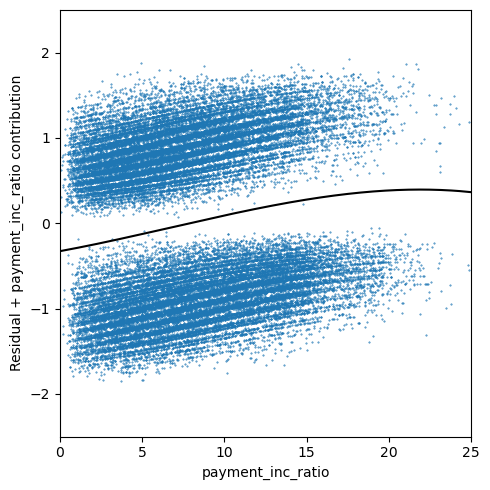

In [2337]:
from statsmodels.genmod.generalized_linear_model import GLMResults
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    '''
    The function expects model to be a statsmodels GLM results object (e.g.,
    what you get from smf.glm(...).fit()), plus the data df, the name of the target column outcome, 
    the feature you want to inspect, and a Matplotlib fig, ax to draw on.
    '''
    y_actual = [1 if s == 'default' else 0 for s in df[outcome]]
    y_pred = model.predict(df)
    '''
    y_pred contains the fitted probabilities for each sample:       hat{p}_i = Pr(Y=1 | X_i)
    These are the predicted probabilities that Y=1 given the observed features X_i,
    output by the full model (e.g., logistic regression).
    '''
    # Save params and make a “feature-only” parameter vector:
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    '''
    org_params: keep the original coefficient vector.
    zero_params: copy to mutate.
    Loop: zero out every coefficient whose name does not contain feature.
    For spline terms (e.g., bs(payment_inc_ratio, ...)), this keeps all basis coefficients for that feature.
    This also zeroes the intercept (usually named Intercept or const) because it doesn’t contain feature. 
    That matters below (they later center to offset this).
    '''

    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    '''
    feature_prediction are probabilities from a model where only the feature’s 
    coefficients are active (everything else set to 0, including the intercept).
    '''

    ypartial = -np.log(1/feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    # -log(1/p - 1) is exactly the logit:   logit(p) = log(p / (1 - p))
    # Because the only nonzero coefficients are those tied to your feature,
    # this is essentially the linear predictor contributed by that feature
    # (up to the intercept, which you zeroed).
    
    # The code then mean-centers that curve (subtracts its average)
    # to roughly compensate for having zeroed the intercept.
    # After centering, the feature’s effect oscillates around 0.

    model.initialize(model.model, org_params)
    # Puts the results object back to the true fitted coefficients.
    # (Again, you can avoid this whole dance by using predict(..., params=...).)
    
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': -2 * (y_actual - y_pred),
        'ypartial': ypartial/ 2,
    })
    results = results.sort_values(by=['feature'])
    '''
    feature: the x-values (independent variable being plotted).
    residual: a scaled residual. Here it's -2*(y - p).
    For Bernoulli GLMs, a textbook partial (component-plus-residual) plot uses the working residual: (y - p) / (p * (1 - p)) on the link (logit) scale.
    This code uses a simpler ad-hoc scaling:
      - Multiply the raw residual (y - p) by -2.
      - Later, divide the feature’s logit contribution by 2 (see next line)
      so the two quantities are on comparable scales for visual comparison.
    It’s not a textbook GLM partial residual, but it gives a readable overlay.
    ypartial: feature’s logit contribution, scaled by /2 to match the residual scaling above.
    Sorting by feature makes the overlayed line smooth.
    '''

    ax.scatter(results.feature, results.residual, marker=".", s=72./fig.dpi) # s is the marker size for scatter, and its unit is points² (points squared).
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    '''
    Dots: scaled residuals vs. the feature.
    Black line: estimated contribution of the feature (on the same arbitrary scale as the residuals).
    The y-label reminds you the cloud is “residuals” and the line is the “feature contribution” added on the link scale.
    '''
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()
# What the plot is trying to show:
# A component-plus-residual view for logistic regression:
# - The black curve is the estimated shape f(feature) on the log-odds scale. Since you used bs()/cr() earlier, this can be nonlinear.
# - The points are residual “noise” added on top.
# - If the curve captures the relationship well, the residual cloud should look roughly flat around it (no systematic pattern).


<details>
<summary><span style="color:red">Read more👇</span></summary> 

```python
model.initialize(model.model, zero_params)
feature_prediction = model.predict(df)
```

These two lines temporarily swap the fitted coefficients inside our `statsmodels` results object so that predictions use only the target feature’s terms.


- `model.initialize(model.model, zero_params)`  
  Re-initializes the **results** object with the **same GLM model** (`model.model`) but with a new parameter vector `zero_params`.  
  In our code, `zero_params` has all coefficients set to 0 except those that belong to the feature (and, in our version, the intercept is also zeroed).  
  This does **not** refit the model; it just overwrites the stored params the object will use for prediction.

- `feature_prediction = model.predict(df)`  
  Now that the stored params contain only the feature’s coefficients, `.predict(df)` returns the fitted means under the Binomial-logit model using those params—i.e., the probabilities:
  $$
  \hat p_i = \operatorname{logistic}\!\big(\eta_i\big) = \frac{1}{1 + e^{-\eta_i}},\quad
  \eta_i = \underbrace{x_{i,\text{feature}}^\top \beta_{\text{feature}}}_{\text{only this part; others set to 0}}
  $$
  Since the intercept was zeroed, $\eta_i$ is just the feature’s linear contribution.

Afterwards, our code restores the original parameters with another `initialize(...)`.


**Safer/cleaner alternative (no mutation):**
```python
feature_prediction = model.predict(df, params=zero_params)
```
This computes the same probabilities without altering the results object.


$f_j(x_j)$ is the component (the smooth contribution of feature $x_j$) on the link scale in a GAM/GLM:

$$
\eta_i = \beta_0 + \sum_k f_k(x_{ik}), \quad \text{logit}(p_i) = \eta_i.
$$

A partial residual (aka component-plus-residual) for feature $j$ is the component plus a residual term on the link scale.

For a GLM with link $g$, a first-order approximation gives:

$$
\text{PR}_{ij} \approx \hat{f}_j(x_{ij}) + (y_i - \hat{\mu}_i) g'(\hat{\mu}_i).
$$

For logistic regression $g(\mu) = \text{logit}(\mu)$, so $g'(\mu) = 1/[\mu(1-\mu)]$, hence

$$
\boxed{
\text{PR}_{ij} \approx \hat{f}_j(x_{ij}) + \frac{y_i - \hat{\mu}_i}{\hat{\mu}_i (1 - \hat{\mu}_i)}
}
$$

where $\hat{\mu}_i = \Pr(Y=1 \mid X_i)$.


**Interpretation on the plot**

- The scatter points are the partial residuals $\text{PR}_{ij}$.
- The smooth black line overlaid is the estimated component $\hat{f}_j(x_j)$ (often centered).
- If the model captures the relationship, the cloud should hover around that curve.

So: partial residuals are not just $f_j(x_j)$; they are $f_j(x_j)$ plus a residual term on the link scale.


### **here’s the clean derivation:**

**1) Start from the GLM/GAM model**

For observation $i$:
$$
g(\mu_i) = \eta_i = \beta_0 + \sum_k f_k(x_{ik}), \qquad \mu_i = \mathbb{E}[Y_i \mid X_i].
$$

We want a component-plus-residual (partial residual) for feature $j$: something like
$$
\underbrace{g(Y_i)}_{\text{“response on link scale”}} - \underbrace{\big(\hat\beta_0+\sum_{k\ne j}\hat f_k(x_{ik})\big)}_{\text{everything except }j} \;\approx\; \text{(contribution of }j\text{)}\;+\;\text{(residual)}.
$$

Directly using $g(Y_i)$ is awkward (e.g., for logit, $g(0), g(1)$ blow up). So we linearize $g(Y_i)$ around the fitted mean $\hat\mu_i$.

>**Why we switch to $g(Y_i)$:**
>
>The GLM model operates on the mean:
>$$
g(\mu_i) = \eta_i = \beta_0 + \sum_k f_k(x_{ik})
>$$
>
>A residual must involve the observed response $Y_i$, not just its mean $\mu_i$.  
>So for a component-plus-residual (partial residual) plot, the natural “response on the link scale” is $g(Y_i)$.
>
>**Problem (for logit) and the fix:**
>
>With logistic regression $g = \text{logit}$, $g(0)$ and $g(1)$ are $-\infty$ and $+\infty$.  
>So we can’t literally use $g(Y_i)$.
>
>**Solution:**  
>Linearize $g(Y_i)$ around the fitted mean $\hat\mu_i$ via a first-order Taylor expansion:
>$$
g(Y_i) \approx g(\hat\mu_i) + (Y_i - \hat\mu_i) g'(\hat\mu_i)
>$$
>
>But $g(\hat\mu_i) = \hat\eta_i = \hat\beta_0 + \sum_k \hat f_k(x_{ik})$.


**2) First-order Taylor expansion of the link**

Expand $g(\cdot)$ at $\hat\mu_i$:
$$
g(Y_i)\;\approx\; g(\hat\mu_i) + (Y_i-\hat\mu_i)\,g'(\hat\mu_i).
$$

But $g(\hat\mu_i)=\hat\eta_i=\hat\beta_0+\sum_k \hat f_k(x_{ik})$. Therefore,
$$
g(Y_i)\;\approx\;\hat\eta_i + (Y_i-\hat\mu_i)\,g'(\hat\mu_i).
$$


**3) Isolate the $j$-th component**

Subtract everything except the $j$-term from both sides:
$$
\underbrace{g(Y_i)-\big(\hat\eta_i-\hat f_j(x_{ij})\big)}_{\displaystyle \text{define this as the partial residual } \text{PR}_{ij}}
\;\approx\; \hat f_j(x_{ij}) + (Y_i-\hat\mu_i)\,g'(\hat\mu_i).
$$

So

$$
\text{PR}_{ij} \approx \hat f_j(x_{ij}) + (Y_i-\hat\mu_i)\,g'(\hat\mu_i)
$$

which is the formula you quoted.


**4) Specialize to logistic regression**

For the logit link $g(\mu)=\log \frac{\mu}{1-\mu}$,
$$
g'(\mu)=\frac{d}{d\mu}\log \frac{\mu}{1-\mu} = \frac{1}{\mu(1-\mu)}.
$$

Hence

$$
\boxed{
\text{PR}_{ij} \approx \hat f_j(x_{ij}) + \frac{Y_i-\hat\mu_i}{\hat\mu_i(1-\hat\mu_i)}
}
$$

(the classic “working residual” on the logit scale added to the component).


**5) Sanity check: linear regression case**

If $g(\mu)=\mu$ (identity link), then $g'(\mu)=1$ and
$$
\text{PR}_{ij} \approx \hat f_j(x_{ij}) + (Y_i-\hat\mu_i),
$$
which is exactly the usual component-plus-residual plot for linear models.


That’s all: the key step is the first-order Taylor expansion of the link $g(Y_i)$ around $\hat\mu_i$, which is also the basis of the GLM IRLS algorithm (the “working response” $z_i=\hat\eta_i+(Y_i-\hat\mu_i)g'(\hat\mu_i)$).



### **let’s map the math to exactly what your plot is drawing**  

**What’s on your plot**

**Black line (what you draw):**

You compute  
$$
\text{ypartial}_i = \tfrac{1}{2}\Big(\operatorname{logit}(\hat\mu^{(j)}_i) - \overline{\operatorname{logit}(\hat\mu^{(j)})}\Big)
$$
where $\hat\mu^{(j)}_i$ are predictions made with only the target feature’s coefficients left on (everything else set to $0$).  
Because the logit model is additive on the link scale,
$$
\operatorname{logit}(\hat\mu^{(j)}_i) = \hat f_j(x_{ij}) \quad (\text{up to a constant if you kept the intercept}),
$$
so the line you plot is a centered and halved version of the component
$$
\boxed{ \; \tfrac{1}{2} \big(\hat f_j(x_{ij}) - \overline{\hat f_j} \big)\; }
$$

That “/2” is just a display scaling you added; it’s not part of the theoretical formula.


**Blue dots (what you draw):**

You compute  
$$
\text{residual}_i = -2(y_i - \hat\mu_i)
$$
which is a scaled raw residual on the response (probability) scale.

Hence the two bands you see:  
- If $y_i=1$: $-2(1-\hat\mu_i) \in [-2,0]$  
- If $y_i=0$: $2\hat\mu_i \in [0,2]$


**What the textbook “partial residual” is**  

From the derivation:  
$$
\boxed{ \; \text{PR}_{ij}\;\approx\;\hat f_j(x_{ij})\;+\;\frac{y_i-\hat\mu_i}{\hat\mu_i(1-\hat\mu_i)} \; } \qquad (\text{logit link})
$$
Scatter (theory): plot $\text{PR}_{ij}$  
Line (theory): overlay $\hat f_j(x_{ij})$ (often centered)


**Bottom line: which formulas appear in your plot?**
- **Line:** a centered (and divided-by-2) version of $\hat f_j(x_{ij})$ ✔️
- **Dots:** not $\text{PR}_{ij}$. They are $-2(y - \hat\mu)$, i.e., scaled raw residuals, not the GLM partial residuals.

That’s why your dots don’t “hug” the line—they’re missing the $\frac{y-\hat\mu}{\hat\mu(1-\hat\mu)}$ weighting that puts residuals on the logit scale.


**If you want the textbook partial-residual plot** 

Replace the $y$-values for the dots by the formula and keep the line as the centered component (no /2 needed):
```python
def partial_residual_glm(results, df, outcome, feature, fig, ax):
    y = (df[outcome] == 'default').astype(float)
    mu = results.predict(df) # \hat{\mu}
    # feature-only linear predictor (component) on logit scale
    params_feat = results.params.copy()
    for i, name in enumerate(params_feat.index):
    if feature not in name and name.lower() not in ('const','intercept'):
    params_feat.iloc[i] = 0.0
    p_feat = results.predict(df, params=params_feat)
    fhat = np.log(p_feat / (1 - p_feat)) # = \hat f_j(x) up to a constant
    fhat = fhat - fhat.mean() # center for display
    # GLM partial residuals (logit scale)
    pr = fhat + (y - mu) / (mu * (1 - mu))
    # plot
    order = np.argsort(df[feature].to_numpy())
    ax.scatter(df[feature], pr, marker='.', s=(72./fig.dpi))
    ax.plot(df[feature].to_numpy()[order], fhat[order], color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel("Partial residual & component (logit scale)")
    return ax
```

Now the cloud should sit around the black curve, matching the derivation exactly.



[0.24420955 0.29126668 0.53072354 ... 0.45650871 0.28242882 0.54840535] (45342,)


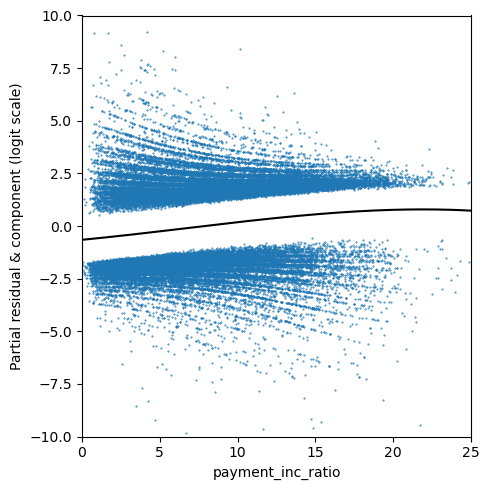

In [2338]:
from patsy import build_design_matrices 
# Patsy helper to rebuild the exact numeric design matrix (splines, dummies, etc.) from the model’s stored formula info.
# Patsy is a small Python library that turns R-style formulas into the numeric design matrices that statistical models need. Statsmodels’ formula API (smf.glm, smf.ols, …) uses Patsy under the hood.

def partialResidualPlot(results, df, outcome, feature, fig, ax):
    '''
    results = the fitted statsmodels GLM results (from the formula API).
    df = data to plot on.
    outcome = name of the target column.
    feature = the predictor you want the partial plot for (e.g., "payment_inc_ratio").
    fig, ax = Matplotlib figure/axes.
    '''
    # 1) Binary target and fitted probs
    y  = (df[outcome] == 'default').astype(float).to_numpy()
    mu = results.predict(df).to_numpy()           # \hat{\mu}
    mu = np.clip(mu, 1e-8, 1-1e-8)                # guard against 0/1
    '''
    Make binary y ∈ {0, 1} with 1 = default.
    mu = hat_mu are fitted probabilities Pr(Y=1 | X).
    Clip mu to avoid division by zero later in (y - mu) / (mu * (1 - mu)).
    np.clip(mu, 1e-8, 1-1e-8) limits all values in mu to the closed interval [1e-8, 1-1e-8].
    Any element < 1e-8 becomes 1e-8.
    Any element > 1 - 1e-8 becomes 1 - 1e-8.
    Values inside the range stay unchanged.
    '''

    # 2) Build the NUMERIC design matrix X for df using the fitted formula
    design_info = results.model.data.design_info   # saved by formula API
    X = build_design_matrices([design_info], df, return_type="dataframe")[0]
    '''
    Grab the formula blueprint (design_info) saved when you fit with smf.glm(...).
    Rebuild X from df exactly as during fitting (same B-splines, same categorical contrasts, same column order).
    '''

    # 3) Keep only intercept + the chosen feature's coefficients
    params_feat = results.params.copy()
    keep_mask = params_feat.index.str.contains(feature) | \
                params_feat.index.str.lower().isin(['const', 'intercept'])
    params_feat.loc[~keep_mask] = 0.0
    '''
    Copy the full coefficient vector.(all betas)
    Build a mask that keeps only:
    coefficients whose names contain the feature string (this catches all spline basis columns for that feature), and
    the intercept.
    Zero out everything else → a “feature-only” parameter vector.
    '''
    # Align coefficients to X's columns (safest) and compute η_feature = X β_feature
    beta_feat = params_feat.reindex(X.columns).fillna(0.0).to_numpy()
    eta_feat = X.to_numpy() @ beta_feat           # linear predictor on logit scale
    fhat = eta_feat - eta_feat.mean()             # center for display
    '''
    Align coefficients to the columns of X (safe!).
    Compute η^(j) = X β_feature: the linear predictor contributed by the chosen feature (plus intercept if you kept it).
    fhat is the estimated component f^j(x) up to a constant; subtract its mean so the line is centered for a nice plot.
    Centering only shifts vertically; it doesn’t change the shape of the curve.
    '''

    # 4) GLM partial residuals on the logit scale:
    pr = fhat + (y - mu) / (mu * (1 - mu))
    '''
    # Compute GLM partial residuals on the logit scale:
    # PR_ij ≈ f̂_j(x_ij) + (y_i - μ̂_i) / (μ̂_i (1 - μ̂_i)).
    # (The second term is the working residual; this is the standard component-plus-residual for logistic regression.)
    '''

    # 5) Plot
    x = df[feature].to_numpy()
    order = np.argsort(x)
    ax.scatter(x, pr, marker='.', s=(72./fig.dpi))
    ax.plot(x[order], fhat[order], color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel("Partial residual & component (logit scale)")
    '''
    # Get the raw feature values, sort them for a smooth line.
    # Scatter the partial residuals PR_ij.
    # Plot the centered component f̂_j(x_j) as a black curve.
    # Label the axes.
    #
    # (Your axis limits (-10, 10) make sense:
    # near μ close to 0 or 1,
    # the factor 1 / [μ(1−μ)] can blow up,
    # so vertical spread grows.)
    # Get the raw feature values and sort them for a smooth line plot.
    # Scatter the partial residuals PR_ij on the plot.
    # Plot the centered component f̂_j(x_j) as a black curve overlay.
    # Label the x-axis with the feature name and y-axis as "Partial residual & component (logit scale)".
    # Note: Axis limits (-10, 10) are reasonable because
    #       near μ close to 0 or 1, the term 1 / [μ(1−μ)] can become very large,
    #       causing the vertical spread of residuals to grow.

    '''
    return ax, mu


fig, ax = plt.subplots(figsize=(5, 5))
ax , m = partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
print(m, m.shape)
ax.set_xlim(0, 25)
ax.set_ylim(-10, 10)


plt.tight_layout()
plt.show()

### **Which formulas are on the plot?**  

From earlier:

**Additive logit model:**

$$
\eta_i = \beta_0 + \sum_k f_k(x_{ik}), \qquad \text{logit}(\mu_i) = \eta_i.
$$

**Partial residual for feature $j$ (logit link):**

$$
\boxed{
\text{PR}_{ij} \approx \hat f_j(x_{ij}) + \frac{y_i - \hat\mu_i}{\hat\mu_i (1 - \hat\mu_i)}
}
$$

On your plot:

- **Black line** = $\hat f_j(x_{ij})$ (centered by a constant).  
  Computed as $X \beta_{\text{feature}} \Rightarrow$ the component on the logit scale.

- **Blue dots** = the right-hand side of the boxed formula, i.e., the partial residuals on the logit scale.

That’s exactly the textbook component-plus-residual visualization for logistic regression. The two “bands” of points appear because $y \in \{0,1\}$;  
the working residual term is positive when $y=1$ and negative when $y=0$, and it inflates when $\mu$ approaches 0 or 1—matching what you see.


### **What does this plot tell us?**

the plot is a component-plus-residual (partial residual) plot for `payment_inc_ratio` on the logit scale.

**What you’re seeing**   

**Black line** = the fitted component  
$$
\hat f_{\text{pay}}(x)
$$ 
from your spline term \texttt{bs(payment_inc_ratio, df=8)}, centered.  
It rises a bit from low $x$, then flattens/slightly dips ⇒ increasing default risk with diminishing returns as payment_inc_ratio grows.

**Blue dots** = partial residuals  
$$
\text{PR}_i \approx \hat f_{\text{pay}}(x_i) + \frac{y_i - \hat\mu_i}{\hat\mu_i (1 - \hat\mu_i)}.
$$

Two bands appear because $y \in \{0,1\}$. Spread gets large where $\hat\mu$ is near 0 or 1 (the $1/[\mu(1-\mu)]$ factor blows up) — expected in logistic models.  

**Diagnostic:** the cloud should “hover around” the black line with no systematic up-or-down drift across $x$.  
Your plot looks broadly well-centered with a smooth, low-wiggle component ⇒ the spline shape you chose is plausible.

**What the plot is for**  

Its main use is to check the functional form for a single feature:

- **Undersmoothed/too rigid** (e.g., linear when curved): points systematically above the line in one region and below in another → increase flexibility (higher df, allow a spline).  
- **Oversmoothed/too wiggly:** a very wavy line chasing noise while the scatter shows no corresponding structure → reduce df or use penalization.  
- **Missing interactions:** color points by another variable; if bands separate with $x$, consider $x \times (\text{other})$ interactions or a 2D smooth.

### **Should you change df in `bs(payment_inc_ratio, df=8)`?**

Use this plot to screen; choose df with out-of-sample criteria:  
- K-fold CV on log-loss (or AUC) across df = 3..10, pick the best.  
- Or switch to a penalized smooth (e.g., GLMGam with B-splines) and tune the smoothing parameter.

Given your plot:  
No clear misspecification pattern; the effect is gentle and mostly monotone.  
You could likely reduce df (e.g., 5–6) without losing shape, but confirm with CV.

**Quick CV sketch (idea)**  



In the following code we run a 5-fold cross-validation to choose the best spline flexibility (df) for `payment_inc_ratio` in a logistic GLM. We compare df=3…9 by mean CV log-loss, then pick the winner:

In [2339]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import log_loss
# Imports: statsmodels (GLM + formulas), KFold splitter, and the log-loss metric (cross-entropy).

# Global bounds (safe for all folds)
# Compute global spline boundaries so every fold’s spline can safely predict on its test set (avoids Patsy’s “outside knots” error).
pay_lo, pay_hi = loan_data["payment_inc_ratio"].min(), loan_data["payment_inc_ratio"].max()
bs_lo,  bs_hi  = loan_data["borrower_score"].min(),   loan_data["borrower_score"].max()

dfs = range(3, 10)
scores = []
kf = KFold(5, shuffle=True, random_state=0)
# Try df = 3…9; prepare 5-fold CV with shuffling for reproducibility.

# Loop over candidate df; for each, split the data into 5 train/test folds.
for d in dfs:
    cv = []
    for tr, te in kf.split(loan_data):
        train = loan_data.iloc[tr].copy()
        test  = loan_data.iloc[te].copy()

        # LHS computed inside the formula; RHS splines with fixed boundaries
        f = (
            f"I(outcome == 'default') ~ "
            f"bs(payment_inc_ratio, df={d}, lower_bound={pay_lo}, upper_bound={pay_hi}) + "
            f"C(purpose_) + C(home_) + C(emp_len_) + "
            f"bs(borrower_score, df=3, lower_bound={bs_lo}, upper_bound={bs_hi})"
        )
        '''
        Build the formula:
        Left side I(outcome == 'default') turns your label into 0/1 inside the formula.
        Right side: a B-spline for payment_inc_ratio with candidate df=d and fixed bounds; 
        categoricals with C(...); and a smaller spline for borrower_score (df=3) with fixed bounds.
        '''

        # Fit a logistic GLM (Binomial + logit) on the train fold.
        res = smf.glm(f, data=train, family=sm.families.Binomial()).fit()

        # Predict default probabilities on the test fold, clip away from 0/1 for numerical safety, compute log-loss, and store it.
        p = res.predict(test).clip(1e-8, 1-1e-8)
        y_true = (test["outcome"] == "default").astype(int)
        cv.append(log_loss(y_true, p))

    scores.append((d, float(np.mean(cv)))) # Average the 5 losses for this d.

# Print per-df performance; pick the df with lowest mean log-loss.
for d, mll in scores:
    print(f"df={d}: mean CV log-loss = {mll:.5f}")

best_df, best_mll = min(scores, key=lambda t: t[1])
'''
scores is a list of tuples like (df, mean_cv_logloss).
This line:

best_df, best_ll = min(scores, key=lambda t: t[1])

does three things:
key=lambda t: t[1] – tells min to compare tuples by their second item (the mean CV log-loss), not the first.
min(scores, key=...) – finds the tuple with the smallest log-loss.
Tuple unpacking – assigns that tuple’s first item to best_df (the winning df) and the second to best_ll (its log-loss).
'''
print(f"\nBest df = {best_df} (mean CV log-loss {best_mll:.5f})")


df=3: mean CV log-loss = 0.88572
df=4: mean CV log-loss = 0.88577
df=5: mean CV log-loss = 0.88632
df=6: mean CV log-loss = 0.88656
df=7: mean CV log-loss = 0.88706
df=8: mean CV log-loss = 0.88715
df=9: mean CV log-loss = 0.88709

Best df = 3 (mean CV log-loss 0.88572)


**TL;DR:** Our partial residual plot is doing exactly what it should—showing the spline component and confirming the relationship looks mild and mostly monotone. Use CV (or a penalized GAM) to finalize how flexible (df) that spline should be.

### **a penalized logistic GAM**

The following code fits a penalized logistic GAM with smooth curves for your continuous variables and categorical effects for your factors, auto-tuning the smoothness. You get calibrated probabilities and interpretable effect shapes without hand-picking spline df.

**Why/when to use this**  

- You want nonlinear effects for continuous features but still an interpretable model.

- You’d rather let the model penalize complexity (λ) than hand-tune spline df.

- You have categoricals too—f() makes them easy to include.

In [2340]:
# pip install pygam
from pygam import LogisticGAM, s, f
import pandas as pd
import numpy as np

y = (loan_data["outcome"] == "default").astype(int).to_numpy()

# Build X as numeric matrix; factors can be passed with 'f()' OR one-hot encoded.
# Here we’ll use pyGAM's factor terms:
gam = LogisticGAM(
        s(0, n_splines=10) +           # payment_inc_ratio
        s(1, n_splines=8)  +           # borrower_score
        f(2) + f(3) + f(4)             # purpose_, home_, emp_len_ (as categorical)
     )
'''
# Defines a logistic Generalized Additive Model:
#   s(i, n_splines=k) = a penalized spline (P-spline) smooth for column i with k basis functions. The model learns a curve f_i(x) and penalizes wiggliness.
#   f(i) = a categorical factor term for column i (learns a separate level effect; no spline).
# The overall model is: logit p = β0 + f1(payment_inc_ratio) + f2(borrower_score) + purpose_ effects + home_ effects + emp_len_ effects.

# In pyGAM, the penalization is applied automatically when you use the s(i, n_splines=k) term for smooth terms. You don't need to manually add the penalty term.
'''

# Arrange columns in that order:
X = np.column_stack([
    loan_data["payment_inc_ratio"].to_numpy(),
    loan_data["borrower_score"].to_numpy(),
    loan_data["purpose_"].astype("category").cat.codes.to_numpy(),
    loan_data["home_"].astype("category").cat.codes.to_numpy(),
    loan_data["emp_len_"].astype("category").cat.codes.to_numpy(),
])
'''
Builds the numeric feature matrix X, matching the column order used in the gam spec.

For factors, cat.codes turns categories into integers (0,1,2,…).
⚠️ If there are missing values, cat.codes gives -1 → clean/encode NAs first.
⚠️ Save the category order and reuse it for new data so codes are consistent.
'''
gam.gridsearch(X, y)         # tunes smoothing automatically
'''
gridsearch fits the GAM and chooses smoothing strengths (the λ’s that control wiggliness) by trying a grid and picking the best via internal validation. You don’t have to hand-pick df—the penalty handles complexity.
predict_proba returns probabilities (on the response scale).

summary() prints fit diagnostics (effective degrees of freedom per term, selected λ’s, deviance, etc.).
'''
proba = gam.predict_proba(X) # probabilities
gam.summary()


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:03
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:03
 27% (3 of 11) |######                   | Elapsed Time: 0:00:01 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:02
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:01
 72% (8 of 11) |##################       | Elapsed Time: 0:00:02 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:02 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02


LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     20.5852
Link Function:                        LogitLink Log Likelihood:                                -28731.2298
Number of Samples:                        45342 AIC:                                            57503.6301
                                                AICc:                                           57503.6516
                                                UBRE:                                               3.2686
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.0858
Feature Function                  Lam

/var/folders/5f/dq45wr613kb8f2bwp4zr0gpc0000gn/T/ipykernel_6461/2122921043.py:45: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


### **What the summary means (quick decode)**

- Model: Logistic GAM (Binomial + logit), n=45,342.  
- Log Likelihood / AIC: overall fit numbers (lower AIC is better when comparing same data / same response models).  
- Pseudo R-Squared = 0.0858: modest lift vs. null; for credit/default that’s common—judge with CV log-loss/AUC instead.  
- Effective DoF (EDoF) = 20.59 total: how much flexibility the penalty actually allowed.  
- s(0) payment_inc_ratio: EDoF ≈ 6.8 out of rank 10 → a smooth but not overly wiggly curve.  
- s(1) borrower_score: EDoF ≈ 4.8 out of rank 8 → also smooth.  
- f(2) purpose_: EDoF = 6.0 with rank 7 → 7 levels → 6 df (level effects vs baseline).  
- f(3) home_: EDoF = 2.0 (3 levels → 2 df).  
- f(4) emp_len_: EDoF = 1.0 (2 levels → 1 df).  
- Lambda [0.2512]: smoothing strength chosen by grid search. (Here it’s the same value applied to all terms; that’s pyGAM’s default when you don’t pass a per-term vector.)  
- p-values / Sig. Code: pyGAM warns these are not reliable when λ is estimated—don’t base inference on them. Use effect plots + CV metrics.  
- The two warnings at the end are standard: p-values are too optimistic when smoothing is tuned; and don’t include a linear term and a spline of the same feature (you didn’t, so you’re fine).

**What to do next**  

1) Look at the shapes. Plot partial effects (with CIs) to sanity-check:



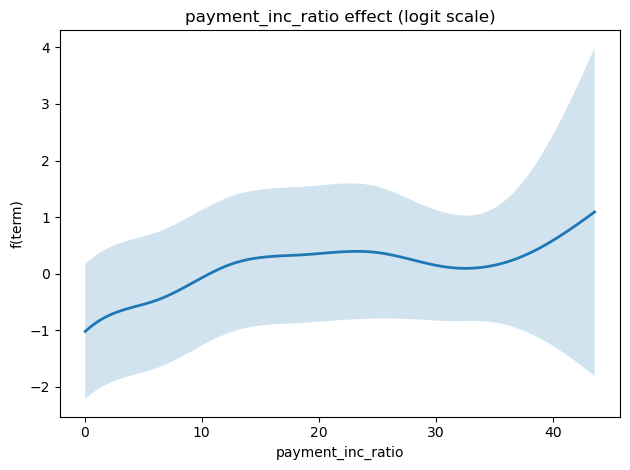

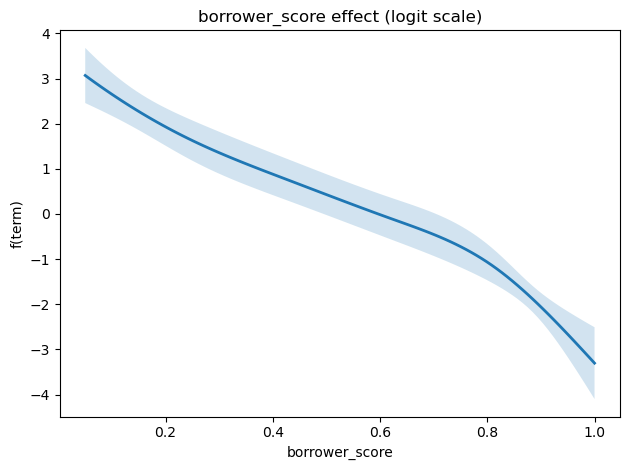

In [2341]:
import matplotlib.pyplot as plt
for term, name in [(0, 'payment_inc_ratio'), (1, 'borrower_score')]:
    XX = gam.generate_X_grid(term=term)                 # grid over that feature
    pd_curve, ci = gam.partial_dependence(term=term, X=XX, width=0.95)
    lo, hi = ci[:, 0], ci[:, 1]
    x = XX[:, term]

    plt.figure()
    plt.plot(x, pd_curve, lw=2)
    plt.fill_between(x, lo, hi, alpha=.2)
    plt.title(f'{name} effect (logit scale)')
    plt.xlabel(name); plt.ylabel('f(term)')
    plt.tight_layout()

plt.show()

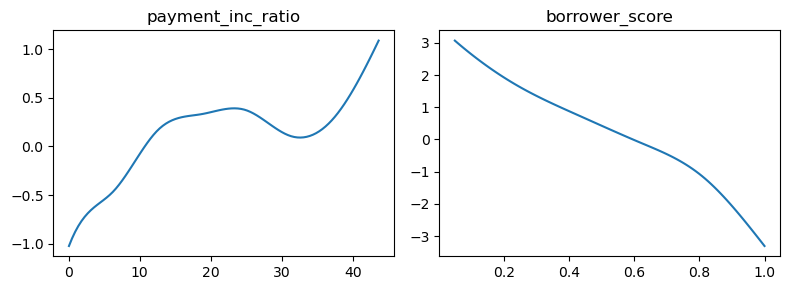

In [2342]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(8,3))
for j, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=j)
    ax.plot(XX[:, j], gam.partial_dependence(term=j, X=XX))
    ax.set_title(["payment_inc_ratio", "borrower_score"][j])
plt.tight_layout()
plt.show()

In [2343]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import numpy as np

X = np.column_stack([
    loan_data["payment_inc_ratio"].to_numpy(),
    loan_data["borrower_score"].to_numpy(),
    loan_data["purpose_"].astype("category").cat.codes.to_numpy(),
    loan_data["home_"].astype("category").cat.codes.to_numpy(),
    loan_data["emp_len_"].astype("category").cat.codes.to_numpy(),
])
y = (loan_data["outcome"] == "default").astype(int).to_numpy()

skf = StratifiedKFold(5, shuffle=True, random_state=42)
ll, auc = [], []
for tr, te in skf.split(X, y):
    g = LogisticGAM(s(0, n_splines=10) + s(1, n_splines=8) + f(2) + f(3) + f(4))
    g.gridsearch(X[tr], y[tr])
    p = g.predict_proba(X[te]).clip(1e-8, 1-1e-8)
    ll.append(log_loss(y[te], p))
    auc.append(roc_auc_score(y[te], p))
print(f'CV log-loss: {np.mean(ll):.4f} ± {np.std(ll):.4f}')
print(f'CV AUC:      {np.mean(auc):.4f} ± {np.std(auc):.4f}')


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:03
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:02
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:01 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:02 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02
  0% (0 of 11) |                        

CV log-loss: 0.6341 ± 0.0018
CV AUC:      0.6919 ± 0.0022


In [2344]:
#Goal:
# Train a plain logistic regression in scikit-learn with a one-hot encoder for categoricals, and report 5-fold stratified CV log-loss and ROC-AUC for P(default).

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import numpy as np


# Splits your features into numeric and categorical lists.
# y is 1 for default, so model probabilities will be P(default).
num = ["payment_inc_ratio", "borrower_score"]
cat = ["purpose_", "home_", "emp_len_"]
X = loan_data[num + cat]
y = (loan_data["outcome"] == "default").astype(int).to_numpy()

pre = ColumnTransformer([
    ("num", "passthrough", num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])
'''
Builds the preprocessor:
    "num": "passthrough" — keep numeric columns as-is (no scaling here).
    "cat": OneHotEncoder(...) — one-hot encode categoricals:
    drop="first" → drops one level per feature to avoid perfect collinearity (reference coding).
    handle_unknown="ignore" → if a test fold has an unseen level, it produces all-zeros for that level instead of erroring.
'''

cv = StratifiedKFold(5, shuffle=True, random_state=42) # 5-fold stratified CV preserves the default rate in each fold.
lls, aucs = [], [] # Lists to collect log-loss and AUC across folds.


for tr, te in cv.split(X, y):
    pipe = make_pipeline(pre, LogisticRegression(C=1e42, solver="liblinear", max_iter=1000))
    pipe.fit(X.iloc[tr], y[tr])
    p = pipe.predict_proba(X.iloc[te])[:, 1].clip(1e-8, 1-1e-8)  # P(default)
    lls.append(log_loss(y[te], p))
    aucs.append(roc_auc_score(y[te], p))
'''
For each train/test split:
    make_pipeline(pre, LogisticRegression(...)) creates a model that first runs the column transformer, then fits logistic regression on the transformed matrix.
    C=1e42 with default penalty='l2' ≈ almost unregularized (mimics statsmodels MLE).
    (If you truly want no penalty, you can use penalty='none', solver='lbfgs' in recent sklearn.)
    solver="liblinear" is a robust choice, especially with one-hot features.
    Important: scikit-learn clones steps inside make_pipeline, so the pre is freshly fit inside each fold (no leakage).
    predict_proba(... )[:, 1] selects the probability of class 1 (= default).
    clip avoids log-loss blow-ups at 0/1.
    Append the fold’s log-loss (probability accuracy; lower is better) and ROC-AUC (ranking; higher is better).
'''
print(f"5-fold CV log-loss: {np.mean(lls):.4f} ± {np.std(lls):.4f}")
print(f"5-fold CV AUC     : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

# or:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.pipeline import make_pipeline
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import StratifiedKFold, cross_validate

# num = ["payment_inc_ratio", "borrower_score"]
# cat = ["purpose_", "home_", "emp_len_"]
# X = loan_data[num + cat]
# y = (loan_data["outcome"] == "default").astype(int).to_numpy()  # 1 = default

# pre = ColumnTransformer(
#     transformers=[
#         ("num", "passthrough", num),
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
#     ]
# )

# clf = LogisticRegression(penalty="l2", C=1e42, solver="liblinear", max_iter=1000)

# pipe = make_pipeline(pre, clf)

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_validate(
#     pipe, X, y, cv=cv,
#     scoring={"logloss": "neg_log_loss", "auc": "roc_auc"},
#     return_train_score=False
# )

# print(f"5-fold CV log-loss: {-scores['test_logloss'].mean():.4f} ± {scores['test_logloss'].std():.4f}")
# print(f"5-fold CV AUC     : {scores['test_auc'].mean():.4f} ± {scores['test_auc'].std():.4f}")



5-fold CV log-loss: 0.6345 ± 0.0019
5-fold CV AUC     : 0.6914 ± 0.0023


In [2345]:
# Goal:
# Run a 5-fold stratified cross-validation of a logistic GLM with B-splines and categoricals, and report CV log-loss and CV AUC for P(default).

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score

# cast once so folds keep the same categories
# Freezes the full set of levels for each factor before splitting, so Patsy uses the same dummy columns in every fold (no level drop/add surprises).
for c in ["purpose_", "home_", "emp_len_"]:
    loan_data[c] = loan_data[c].astype("category")

# global spline bounds
# Fixes boundary knots for splines to the global min/max to avoid Patsy’s “outside knots” error when predicting on test folds.
pay_lo, pay_hi = loan_data["payment_inc_ratio"].min(), loan_data["payment_inc_ratio"].max()
bs_lo,  bs_hi  = loan_data["borrower_score"].min(),   loan_data["borrower_score"].max()

# one formula reused in all folds
formula = (
    f"y ~ bs(payment_inc_ratio, df=3, lower_bound={pay_lo}, upper_bound={pay_hi}) + "
    f"C(purpose_) + C(home_) + C(emp_len_) + "
    f"bs(borrower_score, df=3, lower_bound={bs_lo}, upper_bound={bs_hi})"
)
'''
GLM formula:
y ~ ... → the model will predict P(y=1 | x).
bs(var, df=3, ...) → cubic B-spline basis with 3 columns (df = #basis funcs) on the logit scale.
C(var) → tell Patsy to treat the column as categorical (reference encoding).
'''
y_all = (loan_data["outcome"] == "default").astype(int).to_numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # Make the binary target for stratification (keeps default rate balanced per fold).

lls, aucs = [], []
for tr, te in skf.split(loan_data, y_all):
    train = loan_data.iloc[tr].copy()
    test  = loan_data.iloc[te].copy()
    train["y"] = (train["outcome"] == "default").astype(int)
    test["y"]  = (test["outcome"]  == "default").astype(int)
    # Split into train/test DataFrames.
    # Create explicit y column (1 = default) so .predict(...) returns P(default) (because y is on the LHS).
    res = smf.glm(formula, data=train, family=sm.families.Binomial()).fit() # Fit a logistic GLM (Binomial + logit link) with the spline/categorical terms.
    p = res.predict(test).clip(1e-8, 1-1e-8)   # P(default)     # Predict probabilities of default on the test fold; clip to avoid log(0) in log-loss.

    # Collect log-loss (probability accuracy; lower is better) and ROC-AUC (ranking; higher is better) for this fold.
    lls.append(log_loss(test["y"], p))
    aucs.append(roc_auc_score(test["y"], p))

# Report mean ± std across folds.
print(f"5-fold CV log-loss: {np.mean(lls):.4f} ± {np.std(lls):.4f}")
print(f"5-fold CV AUC     : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


5-fold CV log-loss: 0.6344 ± 0.0020
5-fold CV AUC     : 0.6916 ± 0.0022


In [2346]:
# Goal:
# Fit a penalized logistic GAM (smooths for continuous features + factors for categoricals), tune smoothness by grid search, and report 5-fold stratified CV log-loss & AUC for P(default).
from pygam import LogisticGAM, s, f
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
'''
pyGAM for GAMs; s() = smooth term, f() = factor (categorical) term.
StratifiedKFold keeps class balance per fold; metrics for evaluation.
'''

# ---- data prep (same as before) ----
df = loan_data.copy()
y = (df['outcome'] == 'default').astype(int).to_numpy()

# keep factor coding stable; avoid -1 for NaNs
for c in ['purpose_', 'home_', 'emp_len_']:
    df[c] = df[c].astype('category')
    if df[c].isna().any(): # Checks if the column has any missing values (NaN).
        df[c] = df[c].cat.add_categories(['__MISSING__']).fillna('__MISSING__')
        '''
        If missing values exist:
        .cat.add_categories(['__MISSING__']) → adds a new category label "__MISSING__" to the categorical column.
        .fillna('__MISSING__') → replaces all NaNs with this special category.
        '''

X = np.column_stack([
    df['payment_inc_ratio'].to_numpy(),   # col 0
    df['borrower_score'].to_numpy(),      # col 1
    df['purpose_'].cat.codes.to_numpy(),  # col 2
    df['home_'].cat.codes.to_numpy(),     # col 3
    df['emp_len_'].cat.codes.to_numpy(),  # col 4
])
'''
Build the numeric design matrix. Column order must match the terms you define below:
0→payment_inc_ratio, 1→borrower_score, 2–4→the three factors.
cat.codes gives integer level IDs; because we set categories on the full df, codes are consistent in every fold.
'''
# factory to build a fresh GAM with the same terms
def new_gam():
    return LogisticGAM(
        s(0, n_splines=10) +    # payment_inc_ratio
        s(1, n_splines=8)  +    # borrower_score
        f(2) + f(3) + f(4)      # purpose_, home_, emp_len_
    )
'''
A tiny “factory” that creates a fresh, unfitted model each time (important inside CV).
'''

LAM_GRID = np.logspace(-3, 3, 11)
'''
Candidate λ values (smoothness): small λ → wigglier; large λ → smoother.
Passed to gridsearch so pyGAM picks the best one on the training fold.
'''

# fit on all data (for effect plots etc.)
gam = new_gam()
gam.gridsearch(X, y, lam=LAM_GRID, progress=False)
proba_full = gam.predict_proba(X)
'''
Fit once on all data (useful for effect plots). gridsearch tunes λ; progress=False hides bars.
predict_proba gives P(default) on the full set.
'''

# 5-fold stratified CV
skf = StratifiedKFold(5, shuffle=True, random_state=42)
lls, aucs = [], []
for tr, te in skf.split(X, y):
    g = new_gam()
    g.gridsearch(X[tr], y[tr], lam=LAM_GRID, progress=False)
    p = g.predict_proba(X[te]).clip(1e-8, 1-1e-8)
    lls.append(log_loss(y[te], p))
    aucs.append(roc_auc_score(y[te], p))
'''
5-fold stratified CV: for each fold, build a fresh model, tune λ on the train slice only, then predict on test.
clip guards against log(0) in log-loss.
Collect log-loss (probability quality; lower is better) and ROC-AUC (ranking; higher is better).
'''

# Report mean ± SD across folds.
print(f"CV log-loss: {np.mean(lls):.4f} ± {np.std(lls):.4f}")
print(f"CV AUC:      {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")


CV log-loss: 0.6341 ± 0.0018
CV AUC:      0.6919 ± 0.0022


Not weird at all that these three different models gave us the same results!
it's actually what we’d expect. All three setups are learning essentially the **same additive logistic model** on the **same features**, so their out-of-sample scores land in the same place:

- **sklearn LogisticRegression + OHE:** linear logit in numeric features + dummies for categoricals.  
- **statsmodels GLM + bs(df=3):** also an additive logit; with df=3 (no interior knots for cubic B-splines) the numeric effects are nearly linear over most of the range.  
- **pyGAM:** penalized smooths that, after tuning λ, end up with effective complexity very close to “simple smooth/linear.”

Your data are large and the true relationships (from your GAM partial plots) look monotone and close to logit-linear. So all three models produce almost identical rankings (AUC ≈ 0.692) and very similar probabilities (log-loss ≈ 0.634). The tiny differences you see (±0.002) are just CV noise.

**What it means**

You’re likely at the performance ceiling for these features with an additive logit. Changing the algorithm doesn’t move the needle; better features and interactions will.

It also means your modeling pipeline is stable—good news.


Double-check it’s really “no difference” with paired CV, as in the following code:


In [2347]:
# pip install pygam
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import pygam as pg  # use pg.s / pg.f to avoid name clashes

# ---------- data prep ----------
df = loan_data.copy()

# fill NAs in categoricals and freeze global levels
for c in ['purpose_', 'home_', 'emp_len_']:
    df[c] = df[c].astype('category')
    if df[c].isna().any():
        df[c] = df[c].cat.add_categories(['__MISSING__']).fillna('__MISSING__')

purpose_levels = df['purpose_'].cat.categories.tolist()
home_levels    = df['home_'].cat.categories.tolist()
emp_levels     = df['emp_len_'].cat.categories.tolist()

# spline bounds (global) to avoid "outside knots" in CV
pay_lo, pay_hi = df['payment_inc_ratio'].min(), df['payment_inc_ratio'].max()
bs_lo,  bs_hi  = df['borrower_score'].min(),   df['borrower_score'].max()

# helpers
def codes(s, levels):
    return pd.Categorical(s, categories=levels).codes

def make_X(d):
    return np.column_stack([
        d['payment_inc_ratio'].to_numpy(),           # col 0
        d['borrower_score'].to_numpy(),              # col 1
        codes(d['purpose_'], purpose_levels),        # col 2
        codes(d['home_'],    home_levels),           # col 3
        codes(d['emp_len_'], emp_levels),            # col 4
    ])

y_all = (df['outcome'] == 'default').astype(int).to_numpy()

# ---------- CV setup ----------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lam_grid = np.logspace(-3, 3, 11)

glm_ll, glm_auc, gam_ll, gam_auc = [], [], [], []

for tr, te in skf.split(df, y_all):
    train = df.iloc[tr].copy()
    test  = df.iloc[te].copy()

    # explicit target in GLM to guarantee predict = P(default)
    train['y'] = (train['outcome'] == 'default').astype(int)
    test['y']  = (test['outcome']  == 'default').astype(int)

    # ----- GLM (logistic with bs splines) -----
    formula_glm = (
        "y ~ "
        f"bs(payment_inc_ratio, df=3, lower_bound={pay_lo}, upper_bound={pay_hi}) + "
        f"C(purpose_, Treatment(reference={repr(purpose_levels[0])}), levels={repr(purpose_levels)}) + "
        f"C(home_,    Treatment(reference={repr(home_levels[0])}), levels={repr(home_levels)}) + "
        f"C(emp_len_, Treatment(reference={repr(emp_levels[0])}), levels={repr(emp_levels)}) + "
        f"bs(borrower_score, df=3, lower_bound={bs_lo}, upper_bound={bs_hi})"
    )
    glm = smf.glm(formula_glm, data=train, family=sm.families.Binomial()).fit()
    p_glm = glm.predict(test).clip(1e-8, 1-1e-8)
    glm_ll.append(log_loss(test['y'], p_glm))
    glm_auc.append(roc_auc_score(test['y'], p_glm))

    # ----- GAM (penalized logistic GAM) -----
    X_tr, X_te = make_X(train), make_X(test)
    y_tr, y_te = train['y'].to_numpy(), test['y'].to_numpy()

    gam = pg.LogisticGAM(
        pg.s(0, n_splines=10) + pg.s(1, n_splines=8) + pg.f(2) + pg.f(3) + pg.f(4)
    )
    gam.gridsearch(X_tr, y_tr, lam=lam_grid)
    p_gam = gam.predict_proba(X_te).clip(1e-8, 1-1e-8)
    gam_ll.append(log_loss(y_te, p_gam))
    gam_auc.append(roc_auc_score(y_te, p_gam))

# ---------- report ----------
print(f"GLM  5-fold CV log-loss: {np.mean(glm_ll):.4f} ± {np.std(glm_ll):.4f}")
print(f"GLM  5-fold CV AUC     : {np.mean(glm_auc):.4f} ± {np.std(glm_auc):.44f}")
print(f"GAM  5-fold CV log-loss: {np.mean(gam_ll):.4f} ± {np.std(gam_ll):.4f}")
print(f"GAM  5-fold CV AUC     : {np.mean(gam_auc):.4f} ± {np.std(gam_auc):.4f}")

d_ll  = np.array(gam_ll)  - np.array(glm_ll)
d_auc = np.array(gam_auc) - np.array(glm_auc)
print(f"\nΔ log-loss (GAM - GLM): {d_ll.mean():.5f} ± {d_ll.std():.5f}")
print(f"Δ AUC     (GAM - GLM): {d_auc.mean():.5f} ± {d_auc.std():.5f}")


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:03
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:02
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:01
 72% (8 of 11) |##################       | Elapsed Time: 0:00:02 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:02 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02
  0% (0 of 11) |                        

GLM  5-fold CV log-loss: 0.6344 ± 0.0020
GLM  5-fold CV AUC     : 0.6916 ± 0.00224476297368071935761646429341453767847270
GAM  5-fold CV log-loss: 0.6341 ± 0.0018
GAM  5-fold CV AUC     : 0.6919 ± 0.0022

Δ log-loss (GAM - GLM): -0.00025 ± 0.00028
Δ AUC     (GAM - GLM): 0.00023 ± 0.00006


In [2348]:
y_te

array([1, 1, 1, ..., 0, 0, 0], shape=(9068,))

In [2349]:
p_gam.shape

(9068,)

As you can see those deltas hover around 0 with tiny standard deviation, the models are statistically tied.

### **Where to look for gains**

- **Features:** Adding new predictive variables or engineered interactions (e.g., a 2D smooth for payment_inc_ratio × borrower_score) will likely move the needle more than algorithm tweaks.  
- **Interactions (only if justified):** Try a tensor product smooth in GAM or add interaction terms in GLM and re-run cross-validation.  
- **Calibration:** Check reliability curves and Brier score; choose the model with better calibration even if AUC is tied.  
- **Constraints:** If domain knowledge says borrower_score should be monotone decreasing, enforce it in GAM (e.g., constraints='monotonic_dec') for safer behavior without hurting predictive metrics.


### Summary:

Similar models with the same features ⇒ similar results. That’s a good sign—your modeling is stable.  
Now focus on exploring features, interactions, and improving calibration.


## **Evaluating Classification Models**  

**My Question: For these three models, do I also need to report accuracy in addition to CV log-loss and CV AUC, or are those two sufficient?**

Short answer: you don’t need accuracy unless you’re committing to a specific decision threshold.

Keep (and lead with):  
- CV log-loss → probability quality (proper scoring).  
- CV ROC-AUC → threshold-free discrimination.  
- Often add (if positives are rare): PR-AUC (Average Precision).

Add accuracy only if you’ll operate at a fixed threshold (e.g., approve/deny). In that case, also report precision, recall, F1, specificity, and show a confusion matrix—all at that chosen threshold.


**Why accuracy isn’t enough**  

- It’s threshold-dependent and can look great/awful just by moving the cutoff.  
- It’s misleading with class imbalance. Two models with the same accuracy can have very different risk calibration.

If you do need it, pick the threshold on train/CV (by cost, target precision/recall, or Youden’s J), then evaluate on the test fold:
```python
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

t = 0.30 # your chosen operating threshold (picked on training)
yhat = (p >= t).astype(int) # p = predicted P(default) on the test fold

acc = accuracy_score(y, yhat)
prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average='binary')
cm = confusion_matrix(y, yhat)
```

**TL;DR:** For model comparison, CV log-loss + ROC-AUC (and PR-AUC if imbalanced) are sufficient. Include accuracy & friends only when you’ve fixed an operational threshold and need to communicate real-world tradeoffs.

### **Confusion Matrix**

In [2350]:
loan_data.loc[loan_data[outcome]=='default'].shape[0]

22671

In [2351]:
loan_data.loc[loan_data[outcome]=='paid off'].shape[0]

22671

In [2352]:
loan_data.loc[(loan_data[outcome]!='paid off') & (loan_data[outcome]!='default')].shape[0]

0

Therefore we have a balanced dataset with an equal number of defaulted and paid-off loans.

In [2353]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
'''
pd.get_dummies automatically looks at all columns you pass in (loan_data[predictors]):
    If you explicitly convert something to category, it will definitely be one-hot encoded.
    If it’s already of type object (like string labels), it will also be one-hot encoded.
    If it’s numeric (int/float), it’s left as-is.
'''
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X, y);

# print('intercept ', logit_reg.intercept_[0])
# print('classes', logit_reg.classes_)
# pd.DataFrame({'coeff': logit_reg.coef_[0]}, 
#              index=X.columns)

In [2354]:
# Confusion matrix
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)], [np.sum(false_pos), np.sum(true_neg)]],
                       index=['Y = default', 'Y = paid off'],
                       columns=['Yhat = default', 'Yhat = paid off'])
print(conf_mat)

              Yhat = default  Yhat = paid off
Y = default            14336             8335
Y = paid off            8148            14523


In [2355]:
pred_y

array([False, False,  True, ..., False, False,  True], shape=(45342,))

In [2356]:
print(confusion_matrix(y, logit_reg.predict(X)))

[[14336  8335]
 [ 8148 14523]]


The package *dmba* contains the function `classificationSummary` that prints confusion matrix and accuracy for a classification model.


In [2357]:
classificationSummary(y, logit_reg.predict(X), class_names=logit_reg.classes_)

Confusion Matrix (Accuracy 0.6365)

         Prediction
  Actual  default paid off
 default    14336     8335
paid off     8148    14523


## **Precision, Recall, and Specificity**  
The scikit-learn function `precision_recall_fscore_support` computes **precision**, **recall**, **f-score**, and **support** for each class label. It returns 4 arrays, each aligned with the order of `labels`.

In [2358]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print('Precision', conf_mat[0, 0] / sum(conf_mat[:, 0]))
print('Recall', conf_mat[0, 0] / sum(conf_mat[0, :]))
print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))

Precision 0.6376089663760897
Recall 0.6323496978518812
Specificity 0.6405981209474659


In [2359]:
precision_recall_fscore_support(y, logit_reg.predict(X), labels=['default', 'paid off'])

(array([0.63760897, 0.63535742]),
 array([0.6323497 , 0.64059812]),
 array([0.63496844, 0.63796701]),
 array([22671, 22671]))

**`precision_recall_fscore_support`**  

This function from scikit-learn computes **precision**, **recall**, **f-score**, and **support** for each class label.
It returns 4 arrays, each aligned with the order of `labels`.

**(a) Precision**  

**Formula:**  
$$
\text{Precision} = \frac{TP}{TP + FP}
$$  
- For class default: Among all predicted "default", how many were actually default?  
- For class paid off: Among all predicted "paid off", how many were actually paid off?


**(b) Recall (a.k.a Sensitivity)**  

**Formula:**  
$$
\text{Recall} = \frac{TP}{TP + FN}
$$  
- For class default: Among all actual default cases, how many did we correctly predict as default?  
- For class paid off: Among all actual paid off cases, how many did we correctly predict as paid off?


**(c) F-score (F1-score by default)**  

Harmonic mean of precision and recall:  
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$  
Gives a balance between precision and recall.


**(d) Support**  

Simply the number of true instances for each class in your dataset.  
For example:  
If you had 200 defaults and 800 paid offs in $y$, then support = [200, 800].

**3. Example**

Suppose predictions give you:  
- Precision = [0.70, 0.95]  
- Recall = [0.40, 0.99]  
- F1 = [0.51, 0.97]  
- Support = [200, 800]  

This means:  
- For default, the model struggles (precision 70%, recall only 40%).  
- For paid off, the model is very strong (precision 95%, recall 99%).  
- Dataset is imbalanced (200 vs 800).

✅ So, `precision_recall_fscore_support` is a convenient one-liner to get per-class metrics (precision, recall, f1, support) in the order of the labels you specify.


### **ROC Curve**  

The function `roc_curve` in Scikit-learn calculates all the information that is required for plotting a ROC curve.

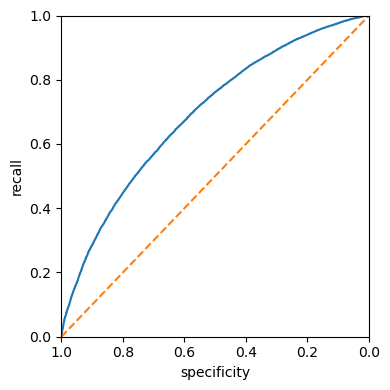

In [2360]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0], pos_label='default')
'''
roc_curve(...) → from sklearn.metrics, computes values needed for ROC.
y → the true labels.
logit_reg.predict_proba(X)[:, 0] → the predicted probabilities for class "default".
Logistic regression outputs probabilities for both classes, here [:, 0] takes the "default" column.
pos_label='default' → tells sklearn that "default" is the positive class (the “1” case).
It returns three arrays:
fpr: False Positive Rates at different thresholds.
tpr: True Positive Rates (i.e., Recall) at those thresholds.
thresholds: the actual cutoff values used.
'''
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})
'''
Converts the ROC results into a dataframe.
tpr = recall.
1 - fpr = specificity.
Because: FPR = 1 - specificity.
So now we have a table with recall vs. specificity at many thresholds.
'''

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
'''
Plots recall (y-axis) vs. specificity (x-axis).
Unlike the typical ROC (which uses FPR), here we use specificity to match textbook/statistics conventions.
'''
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
'''
y-axis fixed between 0 and 1.
x-axis reversed: goes from 1 → 0
'''
ax.plot((1, 0), (0, 1), linestyle='dashed')
'''
Adds a diagonal dashed line from (1,0) to (0,1).
This represents the “random guess” baseline (no better than chance).
If your ROC curve is above this line, the model has predictive power.
'''
ax.set_xlabel('specificity')
ax.set_ylabel('recall')


plt.tight_layout()
plt.show()

In [2361]:
roc_df

,recall,specificity
0,0.000000,1.000000
1,0.000044,1.000000
2,0.000132,1.000000
3,0.000132,0.999956
4,0.000265,0.999956
...,...,...
20187,0.999912,0.001367
20188,0.999956,0.001367
20189,0.999956,0.001279
20190,1.000000,0.001279


🔹 **What FPR really means**

The False Positive Rate (FPR) is defined as:  
$$
\text{FPR} = \frac{FP}{FP + TN}
$$  
- **FP (False Positives):** predicted positive but actually negative.  
- **TN (True Negatives):** predicted negative and actually negative.  

So, FPR is the fraction of actual negatives that were misclassified as positives.



🔹 **Relation to Specificity**

Specificity is:  
$$
\text{Specificity} = \frac{TN}{TN + FP}
$$  

Therefore:  
$$
\text{FPR} = 1 - \text{Specificity}
$$


## **AUC**  

Accuracy can easily be calculated using the scikit-learn function accuracy_score.

In [2362]:
logit_reg.predict_proba(X)

array([[0.24250184, 0.75749816],
       [0.3144073 , 0.6855927 ],
       [0.51662729, 0.48337271],
       ...,
       [0.44768059, 0.55231941],
       [0.2783303 , 0.7216697 ],
       [0.54263247, 0.45736753]], shape=(45342, 2))

In [2363]:
(train['outcome'] == 'default').astype(int)

0        1
1        1
2        1
3        1
4        1
        ..
45336    0
45337    0
45338    0
45339    0
45340    0
Name: outcome, Length: 36274, dtype: int64

In [2364]:
s = [1 if yi == 'default' else 0 for yi in y]
s_series = pd.Series(s)
s_np_array = s_series.to_numpy()
s_np_array

array([1, 1, 1, ..., 0, 0, 0], shape=(45342,))

In [2365]:
y_array = np.array([1 if yi == 'default' else 0 for yi in y], dtype=int)
y_array.shape


(45342,)

In [2366]:
logit_reg.predict_proba(X).shape

(45342, 2)

In [2367]:
print(np.sum(roc_df['recall'][:-1] * np.diff(1 - roc_df['specificity'])))
'''
roc_df['recall'] → this is the TPR (sensitivity) values.
roc_df['specificity'] → so 1 - specificity = FPR (false positive rate).
np.diff(1 - roc_df['specificity']) → computes the incremental changes in FPR between thresholds.
Multiplying recall[:-1] * ΔFPR and summing is basically a left Riemann sum approximation of the area under the ROC curve (integral of TPR wrt FPR).
So this line = manually computing AUC from your ROC points.
'''
print(roc_auc_score([1 if yi == 'default' else 0 for yi in y], logit_reg.predict_proba(X)[:,0]))
# y_true = [1 if yi == 'default' else 0 for yi in y] → binary true labels.
# y_score = logit_reg.predict_proba(X)[:,0] → probability of class "default".
# roc_auc_score → computes AUC using the rank-based definition (equivalent to trapezoid integration, but more robust).

0.6917107913974234
0.6917108692223353


logit_reg.predict_proba(X) → 2-D, while gam.predict_proba(X) (from pyGAM) → 1-D.

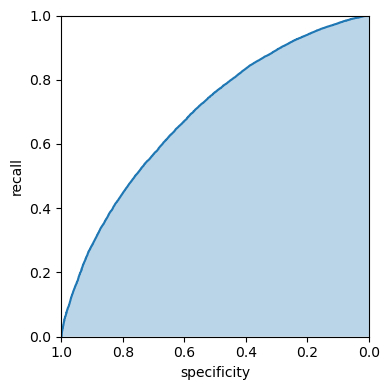

In [2368]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0], 
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
# ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)


plt.tight_layout()
plt.show()

## **Strategies for Imbalanced Data**  
### **Undersampling**  

The results differ from the R version, however are equivalent to results obtained using the R code. Model based results are of similar magnitude.


In [2369]:
full_train_set = pd.read_csv(FULL_TRAIN_SET_CSV)
print(full_train_set.shape)

(119987, 19)


In [2370]:
full_train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119987 entries, 0 to 119986
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   status             119987 non-null  object 
 1   loan_amnt          119987 non-null  int64  
 2   term               119987 non-null  object 
 3   annual_inc         119987 non-null  int64  
 4   dti                119987 non-null  float64
 5   payment_inc_ratio  119987 non-null  float64
 6   revol_bal          119987 non-null  float64
 7   revol_util         119987 non-null  float64
 8   purpose            119987 non-null  object 
 9   home_ownership     119987 non-null  object 
 10  delinq_2yrs_zero   119987 non-null  int64  
 11  pub_rec_zero       119987 non-null  int64  
 12  open_acc           119987 non-null  int64  
 13  grade              119987 non-null  float64
 14  outcome            119987 non-null  object 
 15  emp_length         119987 non-null  int64  
 16  pu

In [2371]:
print('percentage of loans in default: ',100 * np.mean(full_train_set['outcome'] == 'default'))

percentage of loans in default:  18.894546909248504


In [2372]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='', drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
full_model.fit(X, y)
print('percentage of loans predicted to default: ', 100 * np.mean(full_model.predict(X) == 'default'))

percentage of loans predicted to default:  0.750081258803037


In [2373]:
type(full_model.predict(X))
full_model.predict(X).shape

(119987,)

In [2374]:
full_model.classes_

array(['default', 'paid off'], dtype=object)

In [2375]:
100 * np.mean(full_model.predict(X) == 'default')

np.float64(0.750081258803037)

In [2376]:
full_model.predict(X)[888]

'paid off'

In [2377]:
(np.mean(full_train_set.outcome == 'default') / 
 np.mean(full_model.predict(X) == 'default'))

np.float64(25.19)

## **Oversampling and Up/Down Weighting**

In [2378]:
default_wt = 1 / np.mean(full_train_set['outcome'] == 'default')
wt = [default_wt if outcome == 'default' else 1 for outcome in full_train_set['outcome']]

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X, y, wt)
print('percentage of loans predicted to default (weighting): ', 
print(      100 * np.mean(full_model.predict(X) == 'default')))

61.36664805353913
percentage of loans predicted to default (weighting):  None


## **Data Generation**  

The package *imbalanced-learn* provides an implementation of the SMOTE and similar algorithms.

In [2379]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
'''
Uses SMOTE (default sampling_strategy='auto') to oversample the minority class in (X, y) until the two classes are balanced.
'''
print('percentage of loans in default (SMOTE resampled): ', 
      100 * np.mean(y_resampled == 'default'))
'''
Computes the share of 'default' after resampling.
Your output: 50.0 → perfectly balanced 50/50 (expected for SMOTE with binary classes).
'''


# Fits a (practically unregularized) logistic regression on the resampled data:
full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (SMOTE): ', 100 * np.mean(full_model.predict(X) == 'default'))
'''
Predicts class labels on the original X (threshold = 0.5 implicitly), then reports what % are predicted 'default'.
Your output: 29.150…% → training on balanced data does not force predictions to be 50% default on new data. 
It reflects the model’s scores vs the 0.5 cutoff on the original (likely imbalanced) set.
Takeaways:
      Balancing the training set helps learning, but it doesn’t force 50% positives when classifying new, imbalanced data at a 0.5 cutoff.
      If you oversample, either adjust the threshold (to π_true or to your cost ratio) or adjust/calibrate the probabilities/intercept to the true prior.
'''

X_resampled2, y_resampled2 = ADASYN().fit_resample(X, y)
print('percentage of loans in default (ADASYN resampled): ', 100 * np.mean(y_resampled2 == 'default'))
'''
Uses ADASYN, which also oversamples the minority class but focuses more on hard-to-learn regions (density-weighted). Total balancing can be slightly off due to integer rounding of synthetic counts.
Your output: 48.5604…% → close to 50%, but not exact (typical with ADASYN because of rounding and per-sample allocation).
'''

# Fits the same logistic model on the ADASYN-resampled data:
full_model2 = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model2.fit(X_resampled2, y_resampled2)
print('percentage of loans predicted to default (ADASYN): ', 100 * np.mean(full_model2.predict(X) == 'default'))

percentage of loans in default (SMOTE resampled):  50.0
percentage of loans predicted to default (SMOTE):  29.53486627718003
percentage of loans in default (ADASYN resampled):  48.56040383751355
percentage of loans predicted to default (ADASYN):  27.51714769099986


In [2380]:
100 * np.mean(y == 'default')

np.float64(18.894546909248504)

In [2381]:
100 * np.mean(full_model.predict(X) == 'default')

np.float64(29.53486627718003)

In [2382]:
100 * np.mean(y_resampled == 'default')

np.float64(50.0)

In [2383]:
(y == 'default').mean()

np.float64(0.18894546909248502)

In [2384]:
X.shape

(119987, 13)

In [2385]:
X_resampled.shape

(194632, 13)

In [2386]:
y_resampled.shape

(194632,)

In [2387]:
type(y_resampled)

pandas.core.series.Series

In [2388]:
y.loc[y=='paid off'].shape[0]

97316

In [2389]:
y.loc[y=='default'].shape[0]

22671

In [2390]:
y_resampled.loc[y_resampled=='paid off'].shape[0]

97316

In [2391]:
y_resampled.loc[y_resampled=='default'].shape[0]

97316

## **Exploring the Predictions**

In [2423]:
from pygam import LinearGAM, s

loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', 
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)
'''
Builds a decision tree:
criterion='entropy' → splits chosen by information gain.
min_impurity_decrease=0.003 → a split must reduce impurity by ≥ 0.003, which prunes small/weak splits (helps prevent overfitting).
random_state=1 → reproducible results.
.fit(X, y) learns the tree from your two features.
'''
loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
'''
Fits Linear Discriminant Analysis:
Projects data to maximize class separation assuming class-conditional normals with equal covariance.
Works fine with string class labels; no manual encoding needed.
'''

logit_reg = LogisticRegression(penalty="l2", solver='liblinear')
logit_reg.fit(X, y)
'''
Fits logistic regression:
penalty="l2" (ridge) with solver='liblinear' (solid for small/medium problems).
Scikit-learn will encode string labels internally; you don’t need to map to 0/1 here.
'''

## model
gam = LinearGAM(s(0) + s(1)) # In this case, with ['borrower_score', 'payment_inc_ratio'] as our predictors, LogisticGAM would give us a plot very similar to that of LogisticRegression since these two are fundamentally using the logit function for binary classification. If the relationship between the features and target is not strongly non-linear, even LogisticGAM (which is capable of non-linear modeling) might end up producing decision boundaries very similar to Logistic Regression. so we use LinearGAM as a different model.
print(gam.gridsearch(X.values, [1 if yi == 'default' else 0 for yi in y]))
'''
Builds a Generalized Additive Model with two smooth terms:
s(0) applies a spline to column 0 of X.values (borrower_score).
s(1) applies a spline to column 1 (payment_inc_ratio).
LinearGAM uses a Gaussian/identity link by default (suited to continuous targets).
gridsearch(...) tunes the smoothing parameter(s) (λ) over a grid and fits the model. It expects:
X.values: a NumPy array of shape (n_samples, 2).
The target as numeric; you provide a list comprehension mapping 'default'→1 and others → 0.
print(...) prints the fitted GAM object (its representation).
'''



  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)


"\nBuilds a Generalized Additive Model with two smooth terms:\ns(0) applies a spline to column 0 of X.values (borrower_score).\ns(1) applies a spline to column 1 (payment_inc_ratio).\nLinearGAM uses a Gaussian/identity link by default (suited to continuous targets).\ngridsearch(...) tunes the smoothing parameter(s) (λ) over a grid and fits the model. It expects:\nX.values: a NumPy array of shape (n_samples, 2).\nThe target as numeric; you provide a list comprehension mapping 'default'→1 and others → 0.\nprint(...) prints the fitted GAM object (its representation).\n"

In [ ]:
X.shape # (3000, 2)
y.shape # (3000,)

(3000,)

<Figure size 640x480 with 0 Axes>

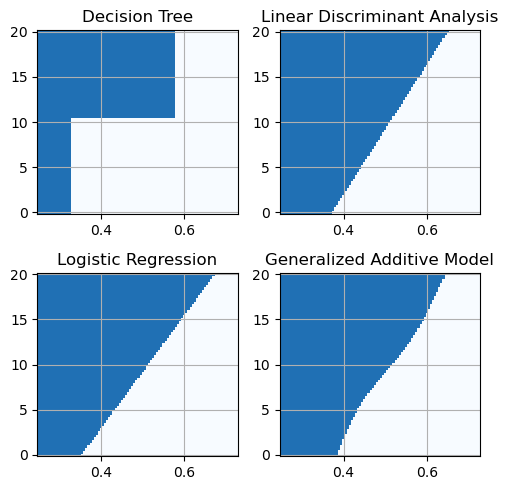

In [ ]:
models = {
    'Decision Tree': loan_tree,
    'Linear Discriminant Analysis': loan_lda,
    'Logistic Regression': logit_reg,
    'Generalized Additive Model': gam,
}
'''
This creates a dictionary called models, where the keys are strings representing the model names, 
and the values are the models themselves (e.g., loan_tree, loan_lda, logit_reg, gam).
The purpose of this dictionary is to store and later iterate over multiple models.
'''

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
'''
This line creates a 2x2 grid of subplots using matplotlib with a figure size of 5x5 inches. The axes object will store the individual subplots (4 axes total, one for each model).
fig represents the entire figure (canvas), and axes is a 2x2 array of subplots.
'''
xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
# np.meshgrid(xvalues, yvalues) creates two 2D arrays (xx and yy) representing all combinations of the xvalues and yvalues grids. 
# This allows you to evaluate predictions over the entire feature space.

# xx.shape # (203, 96)
# yy.shape # (203, 96)
# X.shape # (19488, 2)
# xvalues.shape # (96,)
# yvalues.shape # (203,)
X = pd.DataFrame({
    'borrower_score': xx.ravel(),
    'payment_inc_ratio': yy.ravel(),
})
'''
xx.ravel() and yy.ravel() flatten the 2D arrays xx and yy into 1D arrays.
pd.DataFrame() creates a DataFrame X from the two flattened arrays, which will be used to make predictions for each combination of borrower_score and payment_inc_ratio.
'''

boundary = {} # This creates an empty dictionary called boundary that will store the decision boundaries for each model.

for n, (title, model) in enumerate(models.items()):
    ax = axes[n // 2, n % 2]
    predict = model.predict(X) 
    # print(predict.shape) # (19488,)
    if 'Generalized' in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:
        
        Z = np.array([1 if z == 'default' else 0 for z in predict])
    Z = Z.reshape(xx.shape) # Z: (19488,)-->(203, 96) # Z is the array that holds the predicted class values (0 or 1) for a grid of points created by xx and yy. It's a 2D array that represents the predicted class probabilities (or binary predictions) from the model across all combinations of borrower_score (from xx) and payment_inc_ratio (from yy).=
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)] # np.argmax(Z > 0, axis=0) is a 1D array with shape (96,), where each entry is the index ,in range[0,203), of the first occurrence of 1 along the corresponding column of Z. The Z array has a shape of (203, 96). Each column of Z corresponds to the predictions made by the model for a fixed value of borrower_score (xx), and each row corresponds to a fixed value of payment_inc_ratio (yy). In simpler terms, Z holds the model's predictions over a grid where the first dimension (203) corresponds to different payment_inc_ratio values, and the second dimension (96) corresponds to different borrower_score values.
    # print(type(boundary[title])) # <class 'numpy.ndarray'>
    # print(boundary[title].shape) # (96,)
    # So, boundary[title] will have a shape of (96,), corresponding to the boundary of the model’s decision in the borrower_score dimension (96 different borrower_score values).
    '''
    np.argmax(Z > 0, axis=0): This finds the index of the first True value (i.e., the first value greater than 0) along each column (because axis=0 means searching down each column). In this case, it will return the indices of the first occurrences of True in each column:
    For example, if Z is:
        [[1, 0, 1],
        [0, 1, 0],
        [0, 0, 1]]

    Z > 0 would return:
    [[True, False, True],
    [False, True, False],
    [False, False, True]]

    For the example above, np.argmax(Z > 0, axis=0) would return [0, 1, 0], meaning the first non-zero value in the first column is at index 0, in the second column it's at index 1, and in the third column, it's at index 0.
    yvalues[np.argmax(Z > 0, axis=0)]: The result of np.argmax(Z > 0, axis=0) (which is an array of indices) is then used to index into the yvalues array, which corresponds to the payment_inc_ratio values.
    
    So, if np.argmax(Z > 0, axis=0) gives [0, 1, 0], then yvalues[0], yvalues[1], yvalues[0] would be selected, and these would correspond to the values of payment_inc_ratio where the class prediction (or decision boundary) switches from 0 to 1.
    This essentially identifies the point where the model transitions from predicting the negative class (0) to predicting the positive class (1) for each column in Z.
    '''
    boundary[title][Z[-1,:] == 0] = yvalues[-1] # yvalues.shape # (203,)    Z.shape # (203, 96)
    # Z[-1, :]: This takes the last row of Z, which corresponds to the predictions made at the highest value of payment_inc_ratio (yvalues[-1]) for all borrower_score values.
    # The shape of Z[-1, :] is (96,).
    # Z[-1, :] == 0: Creates a boolean array of shape (96,), where True means the model predicts 0 at the highest payment_inc_ratio for that borrower_score value, and False means it predicts 1.
    # boundary[title][Z[-1,:] == 0] = yvalues[-1]: For every borrower_score where the model still predicts 0 at the highest payment_inc_ratio, it sets the boundary value at that point to the maximum payment_inc_ratio (yvalues[-1]).
    # This ensures that the decision boundary is properly set at the maximum value for any regions where the model might still predict 0 at the upper end of payment_inc_ratio.
    '''
    boundary[title][Z[-1,:] == 0] = yvalues[-1]
    is handling the situation where there are columns in Z where all the values are zero. 
    Here's the breakdown of what's happening:

    Z[-1, :] == 0: This checks if the last row (i.e., Z[-1, :]) in Z is equal to zero. In other words, it's checking if the predicted class for the last yvalue in yvalues is 0. If it is, it means the classifier did not predict a positive class for that part of the feature space, so it doesn't have a positive decision boundary.

    boundary[title][Z[-1,:] == 0] = yvalues[-1]: This line assigns yvalues[-1] (the maximum payment_inc_ratio value in this case) to the boundary for those specific columns (or indices) in boundary[title] where the condition Z[-1, :] == 0 is true.

    Effectively, for columns in Z that have all zero values, this ensures that the boundary value for those specific regions is set to the last value in yvalues (which might correspond to the maximum of the feature space).

    Why is this necessary?
    When Z contains all zeros in a column (meaning no positive prediction was made for that part of the feature space), it implies that there's no active boundary for this region. Thus, setting those indices in boundary[title] to yvalues[-1] ensures that you have a defined boundary at the "edge" of the feature space (or maximum value), ensuring smoothness for the decision boundary plot.
    In short, this line is handling the edge case where certain feature space regions have no positive class prediction (all zero values in that column of Z), by assigning the boundary for those regions to the last value of the feature (yvalues[-1]).
    '''
    
    
    
    '''
    Looping through models: This for loop iterates over each model in the models dictionary:
    n is the index (0 to 3).
    title is the name of the model (e.g., 'Decision Tree', 'Linear Discriminant Analysis', etc.).
    model is the actual model object (e.g., loan_tree, loan_lda).

    Plotting:
    ax = axes[n // 2, n % 2]: This selects the subplot (axis) for the current model (n // 2 for row and n % 2 for column).
    predict = model.predict(X): This generates predictions for the X dataset.

    If the model is Generalized Additive Model (GAM), it assigns the class label based on a threshold of 0.5.
    Z = np.array([1 if z > 0.5 else 0 for z in predict])


    For other models, the predictions are expected to be 'default' or 'paid off', so it assigns the class label as 1 or 0 based on whether the prediction is 'default':
    Z = np.array([1 if z == 'default' else 0 for z in predict])


    Z.reshape(xx.shape): Reshapes the Z array to match the grid dimensions (matching xx.shape).
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]: Finds the boundary (cutoff point) where the predicted class changes from 0 to 1 and stores it in the boundary dictionary.

    boundary[title][Z[-1,:] == 0] = yvalues[-1]: Handles the case where the predicted class is 0 at the far end of the y values.
    '''
    c = ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto')
    ax.set_title(title)
    ax.grid(True)
    ''''
    ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto'):
    This plots the decision boundaries on the grid using a color mesh, where each cell is colored based on the predicted class (Z).

    cmap='Blues': Specifies the color scheme (blue tones).
    vmin=0.1, vmax=1.3: Defines the minimum and maximum values for the color scale.

    shading='auto': Ensures that the mesh is plotted with automatic shading.

    ax.set_title(title): Sets the title for the subplot, corresponding to the model.

    ax.grid(True): Adds a grid to the subplot for easier visual reference.
    '''
plt.tight_layout()
plt.show()
plt.tight_layout()
# Adjusts the layout of the subplots to prevent overlap and ensure that the plots are neatly spaced.
# plt.show(): Displays the figure with all the subplots.

This plot shows decision boundaries for four different classification models, each applied to a dataset with two features (`borrower_score` and `payment_inc_ratio`):

1. **Decision Tree** (Top-left plot):

   * The decision tree model creates a **step-like** boundary. It splits the feature space into distinct regions based on specific thresholds.
   * The sharp changes in the boundary reflect how decision trees handle data. For example, if `borrower_score` is above a certain threshold, the prediction might flip from `0` (not default) to `1` (default) instantly. This results in the piecewise structure that you see in the plot.

2. **Linear Discriminant Analysis (LDA)** (Top-right plot):

   * LDA tries to **find a linear decision boundary** between the two classes. Here, the model creates a straight diagonal line as the decision boundary. The model assumes that the data from each class follow a Gaussian distribution with the same covariance and maximizes class separation. In the plot, the gradual shift from one class to the other is represented smoothly.
   * This shows that LDA assumes a linear relationship and is not as flexible as decision trees in separating classes, but it's computationally efficient and interpretable.

3. **Logistic Regression** (Bottom-left plot):

   * Like LDA, logistic regression also draws a **linear decision boundary** (diagonal). However, logistic regression directly models the probability of belonging to one class (in this case, default), whereas LDA focuses on maximizing class separation.
   * The logistic regression boundary is more flexible than LDA since it doesn't assume identical covariances for both classes and works well with nonlinear relationships in the data.

4. **Generalized Additive Model (GAM)** (Bottom-right plot):

   * The GAM model allows for **smooth, nonlinear boundaries**. In this plot, the decision boundary is not a simple straight line but a smoother curve that adapts to the data.
   * GAMs create a more flexible boundary compared to LDA or logistic regression by allowing for nonlinear relationships between the features and the outcome.
   * The model fits splines for each feature (`borrower_score` and `payment_inc_ratio`) and uses them to adjust the boundary in a more complex, nonlinear way.

### Summary of Differences:

* **Decision Tree**: Creates step-wise boundaries, highly flexible, can overfit.
* **LDA**: Linear boundary, assumes classes have identical covariance, simple but limited to linear decision boundaries.
* **Logistic Regression**: Linear boundary, models probabilities, works well for binary classification.
* **GAM**: Flexible, smooth decision boundary, handles nonlinear relationships better.

This comparison illustrates how different models can capture different levels of complexity and flexibility in their decision boundaries.


Determining the "better" model depends on several factors, including the data's underlying patterns, the goal of the analysis, and the performance metrics. Here's a breakdown of each model's characteristics and when it might be preferred:

### 1. **Decision Tree**

* **Pros**:

  * Highly flexible and interpretable.
  * Can model non-linear relationships and interactions between features.
  * Works well with both numerical and categorical data.
  * Non-parametric (doesn’t assume any specific distribution of the data).
* **Cons**:

  * Prone to overfitting, especially with deep trees and noisy data.
  * Can struggle with small changes in the data or outliers (leading to high variance).
* **When to use**:

  * When interpretability and simplicity are important.
  * When you suspect non-linear relationships and interactions between features.
* **Best for**: Simple problems or cases where interpretability is crucial.

### 2. **Linear Discriminant Analysis (LDA)**

* **Pros**:

  * Fast and efficient for problems where classes are linearly separable.
  * Works well when the data is approximately normally distributed for each class with equal covariance.
* **Cons**:

  * Assumes normality and equal covariances, which may not hold in real-world data.
  * Struggles with complex non-linear decision boundaries.
* **When to use**:

  * When the relationship between the features and the target is expected to be linear.
  * When you have normally distributed data with similar variances for each class.
* **Best for**: When the classes are linearly separable, and simplicity and speed are required.

### 3. **Logistic Regression**

* **Pros**:

  * Simple, interpretable, and provides probability estimates for classification.
  * Efficient for binary classification tasks.
  * Good performance with linearly separable data.
* **Cons**:

  * Assumes linearity between the features and log-odds of the target.
  * Struggles with complex relationships and non-linear patterns in data.
* **When to use**:

  * When the relationship between features and the outcome is linear.
  * When you need probabilities for classification.
* **Best for**: Simple binary classification problems with linear relationships.

### 4. **Generalized Additive Model (GAM)**

* **Pros**:

  * Flexible and can handle non-linear relationships between features and the target.
  * Provides smooth, interpretable decision boundaries.
  * Works well with both numerical and categorical data.
* **Cons**:

  * Can be computationally expensive for large datasets.
  * May overfit if too many basis functions are used.
* **When to use**:

  * When you suspect complex, non-linear relationships between features and the target.
  * When flexibility is required without making strong parametric assumptions.
* **Best for**: Non-linear relationships where interpretability is still important.

---

### Which model is better?

**It depends on the context:**

* If you have a **non-linear relationship** between features and the target, **Decision Trees** or **GAMs** are more likely to perform better.
* If the data is mostly **linearly separable**, **Logistic Regression** or **LDA** would be more efficient and simple to implement.
* If **interpretability** is important and you need to understand the decision-making process, **Decision Trees** and **Logistic Regression** provide straightforward insights.

### Performance Metrics:

* **Accuracy**: If you care about how many instances are correctly classified, **Logistic Regression** or **LDA** might be better if the data is linearly separable.
* **AUC**: If the problem involves rare events or imbalanced data, **Logistic Regression** or **GAMs** are more reliable because they give probabilistic outputs and can handle imbalances better.
* **Log-Loss**: If you're interested in the confidence of predictions, **GAMs** and **Logistic Regression** will give more probabilistic outputs compared to Decision Trees.

### Conclusion:

* **Use Decision Trees or GAMs** when the data likely has complex, non-linear patterns.
* **Use Logistic Regression or LDA** when the data can be reasonably assumed to have a linear decision boundary.

If you're unsure about which model to choose, **cross-validation** and performance metrics like **AUC**, **log-loss**, and **accuracy** will help you assess and compare them effectively.


In [2438]:
xx

array([[0.25 , 0.255, 0.26 , ..., 0.715, 0.72 , 0.725],
       [0.25 , 0.255, 0.26 , ..., 0.715, 0.72 , 0.725],
       [0.25 , 0.255, 0.26 , ..., 0.715, 0.72 , 0.725],
       ...,
       [0.25 , 0.255, 0.26 , ..., 0.715, 0.72 , 0.725],
       [0.25 , 0.255, 0.26 , ..., 0.715, 0.72 , 0.725],
       [0.25 , 0.255, 0.26 , ..., 0.715, 0.72 , 0.725]], shape=(203, 96))

In [2434]:
xx.shape

(203, 96)

In [2439]:
yy

array([[-0.1, -0.1, -0.1, ..., -0.1, -0.1, -0.1],
       [ 0. ,  0. ,  0. , ...,  0. ,  0. ,  0. ],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1,  0.1],
       ...,
       [19.9, 19.9, 19.9, ..., 19.9, 19.9, 19.9],
       [20. , 20. , 20. , ..., 20. , 20. , 20. ],
       [20.1, 20.1, 20.1, ..., 20.1, 20.1, 20.1]], shape=(203, 96))

In [2440]:
yy.shape

(203, 96)

In [ ]:
X.shape # (19488, 2)

(19488, 2)

In [2430]:
o = loan_tree.predict(X)
o.shape # (19488,)
o

array(['default', 'default', 'default', ..., 'paid off', 'paid off',
       'paid off'], shape=(19488,), dtype=object)

In [2433]:
o = gam.predict(X)
o.shape # (19488,)
o

array([0.65574368, 0.65050774, 0.64522028, ..., 0.41181457, 0.40533732,
       0.39886269], shape=(19488,))

In [2435]:
type(yvalues)

numpy.ndarray

In [2420]:
xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
'''
xx, yy = np.meshgrid(xvalues, yvalues) creates two 2D arrays (grids) from these 1D arrays xvalues and yvalues.
xx will be a 2D array where each row is a copy of xvalues, repeated for every value in yvalues.
yy will be a 2D array where each column is a copy of yvalues, repeated for every value in xvalues.
'''
xx.shape # (203, 96)
yy.shape # (203, 96)
xvalues.shape # (96,)
yvalues.shape # (203,)
yy
xx.ravel()
X 

,borrower_score,payment_inc_ratio
0,0.250,-0.1
1,0.255,-0.1
2,0.260,-0.1
3,0.265,-0.1
4,0.270,-0.1
...,...,...
19483,0.705,20.1
19484,0.710,20.1
19485,0.715,20.1
19486,0.720,20.1


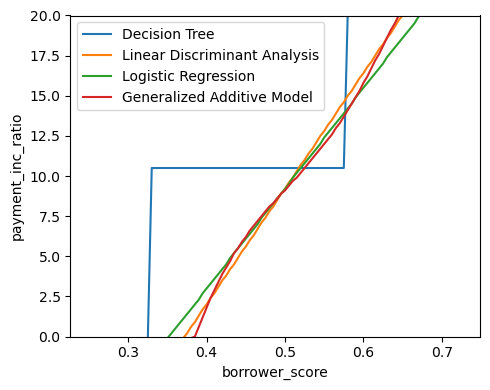

In [2402]:
boundary['borrower_score'] = xvalues
boundaries = pd.DataFrame(boundary)

fig, ax = plt.subplots(figsize=(5, 4))
boundaries.plot(x='borrower_score', ax=ax)
ax.set_ylabel('payment_inc_ratio')
ax.set_ylim(0, 20)


plt.tight_layout()
plt.show()

In [2449]:
boundaries

,Decision Tree,Linear Discriminant Analysis,Logistic Regression,Generalized Additive Model,borrower_score
0,-0.1,-0.1,-0.1,-0.1,0.250
1,-0.1,-0.1,-0.1,-0.1,0.255
2,-0.1,-0.1,-0.1,-0.1,0.260
3,-0.1,-0.1,-0.1,-0.1,0.265
4,-0.1,-0.1,-0.1,-0.1,0.270
...,...,...,...,...,...
91,20.1,20.1,20.1,20.1,0.705
92,20.1,20.1,20.1,20.1,0.710
93,20.1,20.1,20.1,20.1,0.715
94,20.1,20.1,20.1,20.1,0.720


Let's break down the code:

### 1. **Assigning `borrower_score` to `boundary`**

```python
boundary['borrower_score'] = xvalues
```

* This line assigns the `xvalues` array to the key `'borrower_score'` in the `boundary` dictionary.
* `xvalues` likely represents a range of values for the `borrower_score` feature, and this assignment means that the `boundary` dictionary will store `borrower_score` values as the independent variable in the plot.

### 2. **Creating a DataFrame from the `boundary` Dictionary**

```python
boundaries = pd.DataFrame(boundary)
```

* This line converts the `boundary` dictionary into a pandas DataFrame called `boundaries`.
* Each key in the dictionary (e.g., `'borrower_score'`, `'payment_inc_ratio'`, etc.) will become a column in the DataFrame.
* This makes it easier to work with and visualize the data.

### 3. **Creating a Plot**

```python
fig, ax = plt.subplots(figsize=(5, 4))
```

* This line creates a new figure and axis for plotting using `matplotlib`.
* `figsize=(5, 4)` sets the figure size to 5 inches by 4 inches.
* `fig` is the entire figure, and `ax` is the individual subplot (axis).

### 4. **Plotting the Data**

```python
boundaries.plot(x='borrower_score', ax=ax)
```

* This line uses the `plot()` method from `pandas` to plot the `boundaries` DataFrame.
* The argument `x='borrower_score'` tells pandas to use the `borrower_score` column as the x-axis.
* The `ax=ax` argument specifies that the plot should be drawn on the axis `ax` (i.e., the subplot created earlier).
* By default, pandas will plot the other columns (e.g., `Decision Tree`, `Linear Discriminant Analysis`, `Logistic Regression`, `Generalized Additive Model`) against `borrower_score` on the y-axis.

### 5. **Setting the Y-axis Label**

```python
ax.set_ylabel('payment_inc_ratio')
```

* This sets the y-axis label to `'payment_inc_ratio'`, which tells the viewer that the values on the y-axis represent the `payment_inc_ratio` feature.

### 6. **Setting Y-axis Limits**

```python
ax.set_ylim(0, 20)
```

* This sets the limits for the y-axis to range from 0 to 20. It ensures that the plot displays only values within this range for `payment_inc_ratio`, which could be useful if you want to focus on a specific subset of data.

### 7. **Adjust Layout**

```python
plt.tight_layout()
```

* This adjusts the layout of the plot to make sure that everything fits properly, preventing labels or titles from being cut off.

### 8. **Show the Plot**

```python
plt.show()
```

* This line displays the plot, making it visible in the output.

### Summary

This code snippet:

1. Adds `borrower_score` to the `boundary` dictionary.
2. Converts the `boundary` dictionary into a `pandas DataFrame` for easier plotting.
3. Plots the `payment_inc_ratio` against `borrower_score`.
4. Sets up the plot's appearance, including y-axis labels and limits.
5. Finally, it displays the plot.

The resulting plot will show the relationship between `borrower_score` and `payment_inc_ratio` as calculated by the decision boundary or model being used. This can help to visualize how `borrower_score` influences `payment_inc_ratio` in the context of your classification model.
